Monte Carlo:   0%|          | 0/3000 [00:00<?, ?it/s]


Base Simulation Summary:
  strategy  mean_objective  std_objective      p05      p50      p95  \
0       FI         21.0377         4.9049  13.4818  20.8704  29.4252   
1      CJP         20.9469         4.8772  13.2456  20.7405  29.1156   
2       PI         20.9653         4.9012  13.3515  20.7359  29.3468   

   mean_fills  mean_spread  
0     21.5867       2.1148  
1     21.6287       2.1148  
2     21.6193       2.1148  


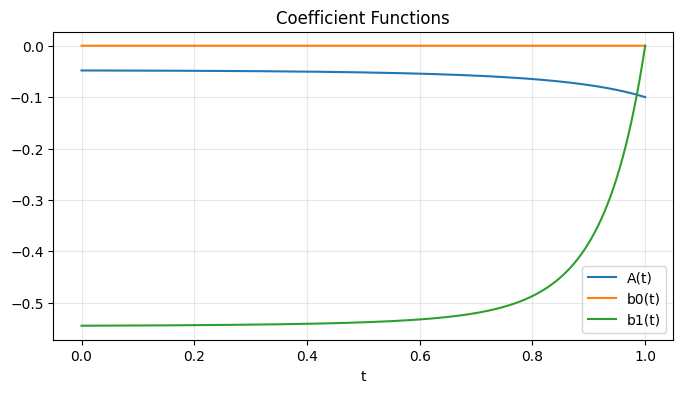

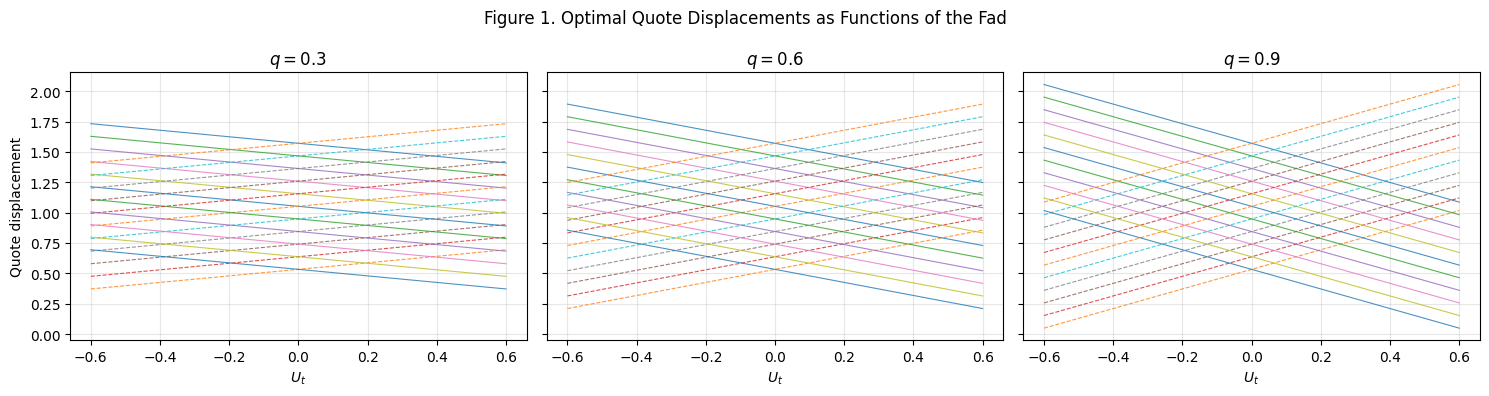

c:\Users\Zack66Fair\miniconda3\envs\torch310_mini\lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Zack66Fair\miniconda3\envs\torch310_mini\lib\site-packages\numpy\_core\_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


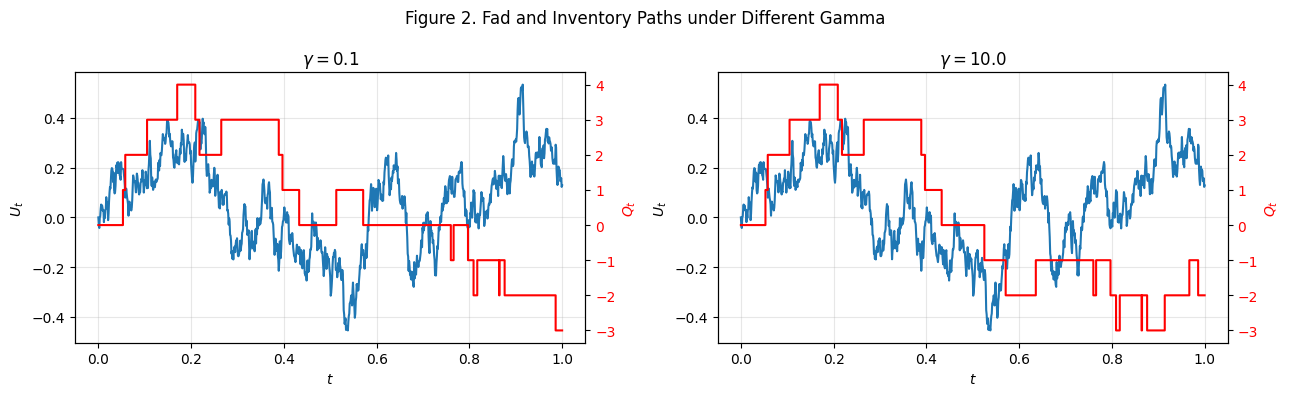

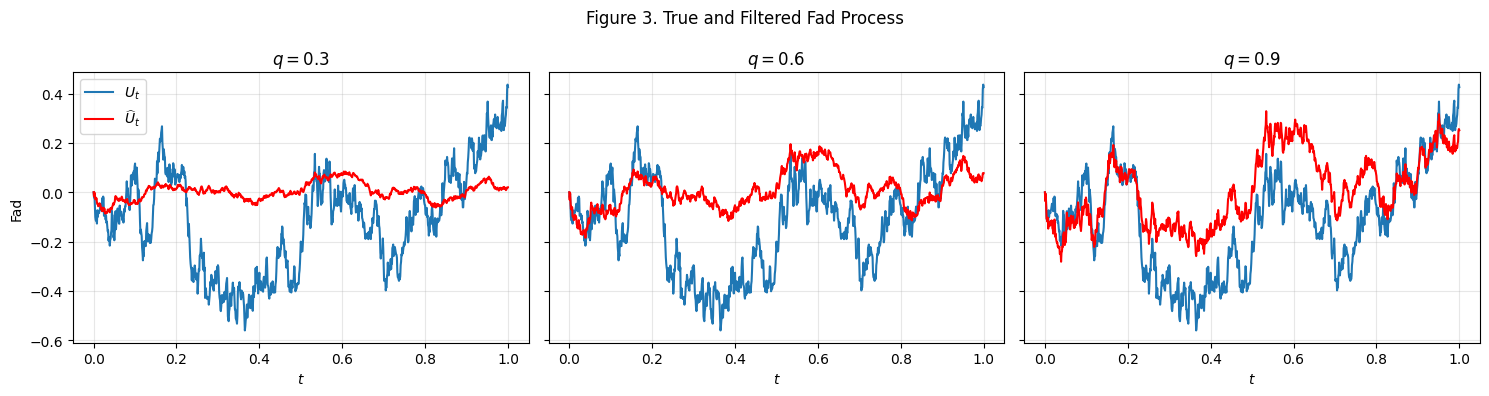

q-grid:   0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
# ============================================================
# Market Making with Fads, Informed and Uninformed Traders
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from tqdm.auto import tqdm

np.random.seed(42)

# ============================================================
# 1. Parameters
# ============================================================

params = {
    "T": 1.0,
    "N": 1000,
    "n_paths": 3000,

    # price and fad
    "mu": 0.0,
    "sigma": 1.0,
    "eta": 10.0,
    "q_fad": 0.6,

    # market order arrival parameters
    "phi": 15.0,
    "psi": 15.0,

    # quote intensity decay
    "k": 1.0,

    # informed sensitivity
    "gamma": 1.0,

    # inventory penalties
    "alpha": 0.1,
    "varphi": 0.1,

    # inventory bounds
    "q_lower": -10,
    "q_upper": 10,

    # lower quote displacement bound
    "delta_a_inf": 5.0,
    "delta_b_inf": 5.0,

    # initial values
    "S0": 100.0,
    "Q0": 0.0,
    "X0": 0.0,
}

# ============================================================
# 2. Utility
# ============================================================

def copy_params(base, **kwargs):
    p = base.copy()
    p.update(kwargs)
    q = p["q_fad"]
    p["p_noise"] = np.sqrt(max(1.0 - q**2, 0.0))
    return p


def lambda_ask(delta_a, u_true, q_inventory, p):
    if q_inventory <= p["q_lower"] or not np.isfinite(delta_a):
        return 0.0

    toxic = p["sigma"] * p["q_fad"] * u_true
    intensity = (
        p["phi"] + p["psi"] * np.exp(-p["gamma"] * toxic)
    ) * np.exp(-p["k"] * delta_a)

    return max(float(intensity), 0.0)


def lambda_bid(delta_b, u_true, q_inventory, p):
    if q_inventory >= p["q_upper"] or not np.isfinite(delta_b):
        return 0.0

    toxic = p["sigma"] * p["q_fad"] * u_true
    intensity = (
        p["phi"] + p["psi"] * np.exp(p["gamma"] * toxic)
    ) * np.exp(-p["k"] * delta_b)

    return max(float(intensity), 0.0)


# ============================================================
# 3. Solve A(t), b0(t), b1(t)
# ============================================================

def terminal_zero_linear_solution(t_grid, a_grid, c_grid):
    """
    Solve y'(t) + a(t)y(t) + c(t) = 0, y(T)=0.

    Solution:
        y(t) = integral_t^T c(s) exp(-int_t^s a(r)dr) ds
    """
    A_int = cumulative_trapezoid(a_grid, t_grid, initial=0.0)

    h = np.exp(A_int) * c_grid

    rev_int = cumulative_trapezoid(h[::-1], t_grid[::-1], initial=0.0)
    right_int = -rev_int[::-1]

    y_grid = np.exp(-A_int) * right_int
    return y_grid


def solve_coefficients(p):
    T = p["T"]
    k = p["k"]
    phi = p["phi"]
    psi = p["psi"]
    varphi = p["varphi"]
    alpha = p["alpha"]
    mu = p["mu"]
    eta = p["eta"]
    sigma = p["sigma"]
    rho = p["q_fad"]
    gamma = p["gamma"]

    kappa = 4.0 * (phi + psi) * np.exp(-1.0) * k

    t_grid = np.linspace(0.0, T, 5000)

    beta_A = np.sqrt(varphi / kappa)
    r = np.sqrt(varphi * kappa)

    if not np.isclose(np.sqrt(varphi), np.sqrt(kappa) * alpha):
        z = ((beta_A - alpha) / (beta_A + alpha)) * np.exp(2.0 * r * (t_grid - T))
        A_grid = beta_A * (z - 1.0) / (z + 1.0)
    else:
        A_grid = -alpha * np.ones_like(t_grid)

    # b0 ODE:
    # 0 = b0' + mu + kappa A b0
    a0_grid = kappa * A_grid
    c0_grid = mu * np.ones_like(t_grid)
    b0_grid = terminal_zero_linear_solution(t_grid, a0_grid, c0_grid)

    # b1 ODE:
    # 0 = b1' - eta*sigma*rho - eta*b1
    #     + kappa*A*b1
    #     + 4e^-1 psi rho sigma gamma A
    #     + 4e^-1 k gamma rho sigma psi A^2
    a1_grid = -eta + kappa * A_grid

    c1_grid = (
        -eta * sigma * rho
        + 4.0 * np.exp(-1.0) * psi * rho * sigma * gamma * A_grid
        + 4.0 * np.exp(-1.0) * k * gamma * rho * sigma * psi * A_grid**2
    )

    b1_grid = terminal_zero_linear_solution(t_grid, a1_grid, c1_grid)

    def coeff_fun(t):
        t_arr = np.asarray(t)
        A = np.interp(t_arr, t_grid, A_grid)
        b0 = np.interp(t_arr, t_grid, b0_grid)
        b1 = np.interp(t_arr, t_grid, b1_grid)
        return np.array([A, b0, b1])

    return coeff_fun, {
        "t_grid": t_grid,
        "A": A_grid,
        "b0": b0_grid,
        "b1": b1_grid,
        "kappa": kappa,
    }


def get_coeffs(t, coeff_fun):
    A, b0, b1 = coeff_fun(t)
    return float(A), float(b0), float(b1)


# ============================================================
# 4. Quote Rules
# FI: full information, uses true U
# CJP: ignores fad, uses u = 0
# PI: partial information, uses U_hat
# ============================================================

def optimal_quotes(t, Q, u_signal, coeff_fun, p):
    A, b0, b1 = get_coeffs(t, coeff_fun)

    B = b0 + u_signal * b1

    delta_minus_V = (-2.0 * Q + 1.0) * A - B
    delta_plus_V = (2.0 * Q + 1.0) * A + B

    delta_a = 1.0 / p["k"] - delta_minus_V
    delta_b = 1.0 / p["k"] - delta_plus_V

    delta_a = max(delta_a, -p["delta_a_inf"])
    delta_b = max(delta_b, -p["delta_b_inf"])

    if Q <= p["q_lower"]:
        delta_a = np.inf

    if Q >= p["q_upper"]:
        delta_b = np.inf

    return float(delta_a), float(delta_b)


# ============================================================
# 5. Exogenous Shocks
# ============================================================

def generate_shocks(p, rng):
    N = p["N"]
    dt = p["T"] / p["N"]

    return {
        "dB": np.sqrt(dt) * rng.standard_normal(N),
        "dZ": np.sqrt(dt) * rng.standard_normal(N),
        "Ua": rng.random(N),
        "Ub": rng.random(N),
    }


# ============================================================
# 6. Exact Riccati + Kalman-Bucy Filter
# ============================================================

def update_filter(U_hat, P_hat, dS, p, dt):
    """
    Continuous-time Kalman-Bucy filter discretized by Euler.

    Model:
        dU_t = -eta U_t dt + dB_t
        dS_t = (mu - eta sigma rho U_t)dt + sigma dI_t

    Innovation:
        dI_t = dS_t - (mu - eta sigma rho U_hat_t)dt

    Filter:
        dU_hat_t = -eta U_hat_t dt
                   + sigma^{-1}(rho - eta rho P_hat_t)dI_t

    Riccati:
        dP_hat_t/dt =
            - eta^2 rho^2 P_hat_t^2
            - P_hat_t(2 eta - 2 eta rho^2)
            + (1 - rho^2)
    """
    mu = p["mu"]
    sigma = p["sigma"]
    eta = p["eta"]
    rho = p["q_fad"]
    p_noise2 = max(1.0 - rho**2, 0.0)

    dI = dS - (mu - eta * sigma * rho * U_hat) * dt

    K = (rho - eta * rho * P_hat) / max(sigma, 1e-12)

    U_hat_new = U_hat - eta * U_hat * dt + K * dI

    dP = (
        -eta**2 * rho**2 * P_hat**2
        - P_hat * (2.0 * eta - 2.0 * eta * rho**2)
        + p_noise2
    ) * dt

    P_hat_new = max(P_hat + dP, 0.0)

    return float(U_hat_new), float(P_hat_new)


# ============================================================
# 7. Simulate One Path
# ============================================================

def simulate_one_path(p, coeff_fun, shocks, strategy):
    T = p["T"]
    N = p["N"]
    dt = T / N

    mu = p["mu"]
    sigma = p["sigma"]
    eta = p["eta"]
    rho = p["q_fad"]
    p_noise = p["p_noise"]

    S = np.zeros(N + 1)
    U = np.zeros(N + 1)
    U_hat = np.zeros(N + 1)
    P_hat = np.zeros(N + 1)
    Q = np.zeros(N + 1)
    X = np.zeros(N + 1)

    delta_a_arr = np.full(N, np.nan)
    delta_b_arr = np.full(N, np.nan)
    lambda_a_arr = np.zeros(N)
    lambda_b_arr = np.zeros(N)

    S[0] = p["S0"]
    Q[0] = p["Q0"]
    X[0] = p["X0"]

    fill_a_count = 0
    fill_b_count = 0

    for i in range(N):
        t = i * dt

        dB = shocks["dB"][i]
        dZ = shocks["dZ"][i]

        # OU fad
        dU = -eta * U[i] * dt + dB
        U[i + 1] = U[i] + dU

        # price process
        dS = mu * dt + sigma * (rho * dU + p_noise * dZ)
        S[i + 1] = S[i] + dS

        # exact partial-information filter
        U_hat[i + 1], P_hat[i + 1] = update_filter(U_hat[i], P_hat[i], dS, p, dt)

        if strategy == "FI":
            u_signal = U[i]
        elif strategy == "CJP":
            u_signal = 0.0
        elif strategy == "PI":
            u_signal = U_hat[i]
        else:
            raise ValueError("strategy must be FI, CJP, or PI")

        delta_a, delta_b = optimal_quotes(t, Q[i], u_signal, coeff_fun, p)

        delta_a_arr[i] = delta_a if np.isfinite(delta_a) else np.nan
        delta_b_arr[i] = delta_b if np.isfinite(delta_b) else np.nan

        lam_a = lambda_ask(delta_a, U[i], Q[i], p)
        lam_b = lambda_bid(delta_b, U[i], Q[i], p)

        lambda_a_arr[i] = lam_a
        lambda_b_arr[i] = lam_b

        prob_a = min(lam_a * dt, 1.0)
        prob_b = min(lam_b * dt, 1.0)

        dNa = shocks["Ua"][i] < prob_a
        dNb = shocks["Ub"][i] < prob_b

        X[i + 1] = X[i]
        Q[i + 1] = Q[i]

        if dNa:
            X[i + 1] += S[i] + delta_a
            Q[i + 1] -= 1.0
            fill_a_count += 1

        if dNb:
            X[i + 1] -= S[i] - delta_b
            Q[i + 1] += 1.0
            fill_b_count += 1

    terminal_objective = (
        X[-1]
        + Q[-1] * S[-1]
        - p["alpha"] * Q[-1] ** 2
        - p["varphi"] * np.sum(Q[:-1] ** 2) * dt
    )

    avg_spread = np.nanmean(delta_a_arr + delta_b_arr)

    return {
        "S": S,
        "U": U,
        "U_hat": U_hat,
        "P_hat": P_hat,
        "Q": Q,
        "X": X,
        "delta_a": delta_a_arr,
        "delta_b": delta_b_arr,
        "lambda_a": lambda_a_arr,
        "lambda_b": lambda_b_arr,
        "objective": terminal_objective,
        "avg_spread": avg_spread,
        "n_fills": fill_a_count + fill_b_count,
    }


# ============================================================
# 8. Monte Carlo Runner
# ============================================================

def summarize_results(results):
    rows = []

    for strategy, outs in results.items():
        obj = np.array([x["objective"] for x in outs])
        fills = np.array([x["n_fills"] for x in outs])
        spreads = np.array([x["avg_spread"] for x in outs])

        rows.append({
            "strategy": strategy,
            "mean_objective": obj.mean(),
            "std_objective": obj.std(ddof=1),
            "p05": np.quantile(obj, 0.05),
            "p50": np.quantile(obj, 0.50),
            "p95": np.quantile(obj, 0.95),
            "mean_fills": fills.mean(),
            "mean_spread": spreads.mean(),
        })

    return pd.DataFrame(rows)


def run_simulation(p, n_paths=None, seed=42, show_progress=True):
    p = copy_params(p)

    if n_paths is not None:
        p["n_paths"] = n_paths

    coeff_fun, coeff_data = solve_coefficients(p)

    strategies = ["FI", "CJP", "PI"]
    results = {s: [] for s in strategies}
    sample_paths = {}

    rng = np.random.default_rng(seed)

    iterator = range(p["n_paths"])
    if show_progress:
        iterator = tqdm(iterator, desc="Monte Carlo")

    for m in iterator:
        shocks = generate_shocks(p, rng)

        for strategy in strategies:
            out = simulate_one_path(p, coeff_fun, shocks, strategy)
            results[strategy].append(out)

            if m == 0:
                sample_paths[strategy] = out

    summary = summarize_results(results)
    return summary, results, sample_paths, coeff_fun, coeff_data


# ============================================================
# 9. Base Simulation
# ============================================================

summary, results, sample_paths, coeff_fun, coeff_data = run_simulation(
    params,
    n_paths=params["n_paths"],
    seed=42,
    show_progress=True
)

print("\nBase Simulation Summary:")
print(summary.round(4))


# ============================================================
# 10. Diagnostic: Coefficients
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(coeff_data["t_grid"], coeff_data["A"], label="A(t)")
plt.plot(coeff_data["t_grid"], coeff_data["b0"], label="b0(t)")
plt.plot(coeff_data["t_grid"], coeff_data["b1"], label="b1(t)")
plt.xlabel("t")
plt.title("Coefficient Functions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fig_coefficients.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 11. Figure 1: Quote Displacements as Functions of Fad
# ============================================================

u_grid = np.linspace(-0.6, 0.6, 150)
inventory_grid = np.arange(-5, 6, 1)
q_grid = [0.3, 0.6, 0.9]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, qval in zip(axes, q_grid):
    p_tmp = copy_params(params, q_fad=qval)
    coeff_tmp, _ = solve_coefficients(p_tmp)

    for Q0 in inventory_grid:
        da_vals, db_vals = [], []

        for u in u_grid:
            da, db = optimal_quotes(0.5, Q0, u, coeff_tmp, p_tmp)
            da_vals.append(da)
            db_vals.append(db)

        ax.plot(u_grid, da_vals, linewidth=0.8, alpha=0.8)
        ax.plot(u_grid, db_vals, linestyle="--", linewidth=0.8, alpha=0.8)

    ax.set_title(rf"$q={qval}$")
    ax.set_xlabel(r"$U_t$")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Quote displacement")
plt.suptitle("Figure 1. Optimal Quote Displacements as Functions of the Fad")
plt.tight_layout()
plt.savefig("fig_displacements.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 12. Figure 2: Fad and Inventory Paths under Different Gamma
# ============================================================

gamma_grid = [0.1, 10.0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

for ax, gamma_val in zip(axes, gamma_grid):
    p_tmp = copy_params(params, gamma=gamma_val, q_fad=0.6)
    summary_tmp, results_tmp, sample_tmp, coeff_tmp, _ = run_simulation(
        p_tmp,
        n_paths=1,
        seed=123,
        show_progress=False
    )

    sample = sample_tmp["FI"]
    time_grid = np.linspace(0, p_tmp["T"], p_tmp["N"] + 1)

    ax.plot(time_grid, sample["U"], label=r"$U_t$")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$U_t$")
    ax.grid(True, alpha=0.3)

    ax2 = ax.twinx()
    ax2.step(time_grid, sample["Q"], where="post", color="red", label=r"$Q_t$")
    ax2.set_ylabel(r"$Q_t$", color="red")
    ax2.tick_params(axis="y", labelcolor="red")

    ax.set_title(rf"$\gamma={gamma_val}$")

plt.suptitle("Figure 2. Fad and Inventory Paths under Different Gamma")
plt.tight_layout()
plt.savefig("fig_gamma_paths.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 13. Figure 3: True and Filtered Fad
# ============================================================

q_grid = [0.3, 0.6, 0.9]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, qval in zip(axes, q_grid):
    p_tmp = copy_params(params, q_fad=qval)
    summary_tmp, results_tmp, sample_tmp, coeff_tmp, _ = run_simulation(
        p_tmp,
        n_paths=1,
        seed=321,
        show_progress=False
    )

    sample = sample_tmp["PI"]
    time_grid = np.linspace(0, p_tmp["T"], p_tmp["N"] + 1)

    ax.plot(time_grid, sample["U"], label=r"$U_t$")
    ax.plot(time_grid, sample["U_hat"], label=r"$\widehat U_t$", color="red")
    ax.set_title(rf"$q={qval}$")
    ax.set_xlabel(r"$t$")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Fad")
axes[0].legend()
plt.suptitle("Figure 3. True and Filtered Fad Process")
plt.tight_layout()
plt.savefig("fig_filter.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 14. Figure 4 / Table: Performance versus q
# ============================================================

q_perf_grid = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
q_rows = []

for qval in tqdm(q_perf_grid, desc="q-grid"):
    p_tmp = copy_params(params, q_fad=qval)
    summary_tmp, _, _, _, _ = run_simulation(
        p_tmp,
        n_paths=2500,
        seed=1000 + int(1000 * qval),
        show_progress=False
    )

    for _, row in summary_tmp.iterrows():
        q_rows.append({
            "q": qval,
            "strategy": row["strategy"],
            "mean_objective": row["mean_objective"],
            "std_objective": row["std_objective"],
            "mean_fills": row["mean_fills"],
            "mean_spread": row["mean_spread"],
        })

df_q = pd.DataFrame(q_rows)

print("\nPerformance versus q:")
print(df_q.pivot(index="q", columns="strategy", values="mean_objective").round(4))

plt.figure(figsize=(7, 5))
for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_q[df_q["strategy"] == strategy]
    plt.plot(sub["q"], sub["mean_objective"], marker=marker, label=strategy)

plt.xlabel(r"$q$")
plt.ylabel("Average performance")
plt.title("Figure 4. Performance as a Function of q")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fig_perf_q.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 15. Figure 5 / Table: Performance versus gamma
#     Paper-style: rescale psi when gamma changes
# ============================================================

def psi_rescaled_for_gamma(base_p, gamma_new, gamma_ref=None):
    """
    Rescale psi so that expected informed market arrivals stay constant
    when gamma changes.

    For OU: dU = -eta U dt + dB,
    stationary Var(U) = 1 / (2 eta).

    toxic = sigma * q_fad * U

    E[exp(gamma * toxic)]
    = exp(0.5 * gamma^2 * sigma^2 * q_fad^2 * Var(U)).
    """
    if gamma_ref is None:
        gamma_ref = base_p["gamma"]

    sigma = base_p["sigma"]
    rho = base_p["q_fad"]
    eta = base_p["eta"]

    var_U = 1.0 / (2.0 * eta)

    m_ref = np.exp(0.5 * (gamma_ref * sigma * rho) ** 2 * var_U)
    m_new = np.exp(0.5 * (gamma_new * sigma * rho) ** 2 * var_U)

    return base_p["psi"] * m_ref / m_new


gamma_grid = [0.0, 1.0, 2.0, 3.0]
gamma_rows = []

for gamma_val in tqdm(gamma_grid, desc="gamma-grid"):
    psi_gamma = psi_rescaled_for_gamma(
        params,
        gamma_new=gamma_val,
        gamma_ref=params["gamma"]
    )

    p_tmp = copy_params(
        params,
        gamma=gamma_val,
        psi=psi_gamma
    )

    summary_tmp, _, _, _, _ = run_simulation(
        p_tmp,
        n_paths=2500,
        seed=2000 + int(100 * gamma_val),
        show_progress=False
    )

    for _, row in summary_tmp.iterrows():
        gamma_rows.append({
            "gamma": gamma_val,
            "psi_rescaled": psi_gamma,
            "phi": p_tmp["phi"],
            "strategy": row["strategy"],
            "mean_objective": row["mean_objective"],
            "std_objective": row["std_objective"],
            "mean_fills": row["mean_fills"],
            "mean_spread": row["mean_spread"],
        })

df_gamma = pd.DataFrame(gamma_rows)

print("\nPerformance versus gamma, with psi rescaled:")
print(df_gamma.pivot(index="gamma", columns="strategy", values="mean_objective").round(4))

print("\nRescaled psi values:")
print(
    df_gamma
    .drop_duplicates("gamma")[["gamma", "phi", "psi_rescaled"]]
    .round(6)
)

plt.figure(figsize=(7, 5))

for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_gamma[df_gamma["strategy"] == strategy]
    plt.plot(
        sub["gamma"],
        sub["mean_objective"],
        marker=marker,
        label=strategy
    )

plt.xlabel(r"$\gamma$")
plt.ylabel("Average performance")
plt.title(r"Figure 5. Performance as a Function of $\gamma$ with $\psi$ rescaled")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fig_perf_gamma.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 16. Figure 7 / Table: Performance versus eta
#     Paper-style: rescale psi when eta changes
# ============================================================

def psi_rescaled_for_eta(base_p, eta_new, eta_ref=None):
    """
    Rescale psi so that expected informed market arrivals stay comparable
    when eta changes.

    For OU:
        dU = -eta U dt + dB

    Stationary variance:
        Var(U) = 1 / (2 eta)

    toxic = sigma * q_fad * U

    E[exp(gamma * toxic)]
    = exp(0.5 * gamma^2 * sigma^2 * q_fad^2 * Var(U)).
    """
    if eta_ref is None:
        eta_ref = base_p["eta"]

    gamma = base_p["gamma"]
    sigma = base_p["sigma"]
    rho = base_p["q_fad"]

    var_ref = 1.0 / (2.0 * eta_ref)
    var_new = 1.0 / (2.0 * eta_new)

    m_ref = np.exp(0.5 * (gamma * sigma * rho) ** 2 * var_ref)
    m_new = np.exp(0.5 * (gamma * sigma * rho) ** 2 * var_new)

    return base_p["psi"] * m_ref / m_new


eta_grid = [2.5, 5.0, 7.5, 10.0, 12.5]
eta_rows = []

for eta_val in tqdm(eta_grid, desc="eta-grid"):
    psi_eta = psi_rescaled_for_eta(
        params,
        eta_new=eta_val,
        eta_ref=params["eta"]
    )

    p_tmp = copy_params(
        params,
        eta=eta_val,
        psi=psi_eta
    )

    summary_tmp, _, _, _, _ = run_simulation(
        p_tmp,
        n_paths=2500,
        seed=3000 + int(100 * eta_val),
        show_progress=False
    )

    for _, row in summary_tmp.iterrows():
        eta_rows.append({
            "eta": eta_val,
            "psi_rescaled": psi_eta,
            "phi": p_tmp["phi"],
            "strategy": row["strategy"],
            "mean_objective": row["mean_objective"],
            "std_objective": row["std_objective"],
            "mean_fills": row["mean_fills"],
            "mean_spread": row["mean_spread"],
        })

df_eta = pd.DataFrame(eta_rows)

print("\nPerformance versus eta, with psi rescaled:")
print(df_eta.pivot(index="eta", columns="strategy", values="mean_objective").round(4))

print("\nRescaled psi values:")
print(
    df_eta
    .drop_duplicates("eta")[["eta", "phi", "psi_rescaled"]]
    .round(6)
)

plt.figure(figsize=(7, 5))

for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_eta[df_eta["strategy"] == strategy]
    plt.plot(
        sub["eta"],
        sub["mean_objective"],
        marker=marker,
        label=strategy
    )

plt.xlabel(r"$\eta$")
plt.ylabel("Average performance")
plt.title(r"Figure 7. Performance as a Function of $\eta$ with $\psi$ rescaled")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fig_perf_eta.pdf", bbox_inches="tight")
plt.show()

# ============================================================
# 17. Figure 8: Informed Trader Share
# ============================================================

share_grid = [0.0, 0.25, 0.50, 0.75, 1.0]
share_rows = []
quote_rows = []

total_intensity = params["phi"] + params["psi"]

# fixed diagnostic state
t0 = 0.5
Q0 = 0.0
u_fixed = 0.5        # must be nonzero, otherwise informed-share effect disappears

for share in tqdm(share_grid, desc="informed-share-grid"):
    p_tmp = copy_params(
        params,
        phi=total_intensity * (1.0 - share),
        psi=total_intensity * share,
    )

    summary_tmp, _, _, coeff_tmp, _ = run_simulation(
        p_tmp,
        n_paths=2500,
        seed=4000 + int(1000 * share),
        show_progress=False
    )

    # performance unchanged
    for _, row in summary_tmp.iterrows():
        share_rows.append({
            "share": share,
            "strategy": row["strategy"],
            "mean_objective": row["mean_objective"],
            "std_objective": row["std_objective"],
            "mean_fills": row["mean_fills"],
            "mean_spread": row["mean_spread"],
        })

    # quote diagnostic: fix U_t, do not average over symmetric u-grid
    for strategy in ["FI", "CJP", "PI"]:
        if strategy == "FI":
            u_signal = u_fixed

        elif strategy == "CJP":
            u_signal = 0.0

        elif strategy == "PI":
            # PI observes filtered/attenuated fad, not full true U
            # simple diagnostic approximation
            u_signal = p_tmp["q_fad"] * u_fixed

        da, db = optimal_quotes(
            t=t0,
            Q=Q0,
            u_signal=u_signal,
            coeff_fun=coeff_tmp,
            p=p_tmp
        )

        quote_rows.append({
            "share": share,
            "strategy": strategy,
            "u_signal": u_signal,
            "ask_delta": da,
            "bid_delta": db,
            "total_spread": da + db,
            "quote_skew": da - db,
            "abs_quote_skew": abs(da - db),
        })

df_share = pd.DataFrame(share_rows)
df_quote = pd.DataFrame(quote_rows)

print("\nPerformance versus informed-trader share:")
print(df_share.pivot(index="share", columns="strategy", values="mean_objective").round(4))

print("\nAsk displacement at fixed U_t:")
print(df_quote.pivot(index="share", columns="strategy", values="ask_delta").round(4))

print("\nBid displacement at fixed U_t:")
print(df_quote.pivot(index="share", columns="strategy", values="bid_delta").round(4))

print("\nQuote skew = ask_delta - bid_delta:")
print(df_quote.pivot(index="share", columns="strategy", values="quote_skew").round(4))

print("\nTotal spread:")
print(df_quote.pivot(index="share", columns="strategy", values="total_spread").round(4))


fig, axes = plt.subplots(1, 4, figsize=(22, 4))

# Ask side
for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_quote[df_quote["strategy"] == strategy]
    axes[0].plot(sub["share"], sub["ask_delta"], marker=marker, label=strategy)

axes[0].set_xlabel("Percentage of informed traders")
axes[0].set_ylabel("Ask displacement")
axes[0].set_title(rf"Ask Side, fixed $U_t={u_fixed}$")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bid side
for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_quote[df_quote["strategy"] == strategy]
    axes[1].plot(sub["share"], sub["bid_delta"], marker=marker, label=strategy)

axes[1].set_xlabel("Percentage of informed traders")
axes[1].set_ylabel("Bid displacement")
axes[1].set_title(rf"Bid Side, fixed $U_t={u_fixed}$")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Quote skew
for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_quote[df_quote["strategy"] == strategy]
    axes[2].plot(sub["share"], sub["quote_skew"], marker=marker, label=strategy)

axes[2].set_xlabel("Percentage of informed traders")
axes[2].set_ylabel("Ask - Bid displacement")
axes[2].set_title("Quote Skew")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Performance unchanged
for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_share[df_share["strategy"] == strategy]
    axes[3].plot(sub["share"], sub["mean_objective"], marker=marker, label=strategy)

axes[3].set_xlabel("Percentage of informed traders")
axes[3].set_ylabel("Average performance")
axes[3].set_title("Performance")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.suptitle("Figure 8. Quotes and Performance versus Informed Trader Share")
plt.tight_layout()
plt.savefig("fig_informed_share.pdf", bbox_inches="tight")
plt.show()


# Optional: total spread figure
plt.figure(figsize=(7, 5))

for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_quote[df_quote["strategy"] == strategy]
    plt.plot(sub["share"], sub["total_spread"], marker=marker, label=strategy)

plt.xlabel("Percentage of informed traders")
plt.ylabel("Total spread")
plt.title(rf"Figure 8b. Total Spread at fixed $U_t={u_fixed}$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fig_informed_spread.pdf", bbox_inches="tight")
plt.show()


# Optional: absolute skew figure
plt.figure(figsize=(7, 5))

for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_quote[df_quote["strategy"] == strategy]
    plt.plot(sub["share"], sub["abs_quote_skew"], marker=marker, label=strategy)

plt.xlabel("Percentage of informed traders")
plt.ylabel("Absolute quote skew")
plt.title(rf"Figure 8c. Quote Skew at fixed $U_t={u_fixed}$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fig_informed_skew.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 18. Distribution Diagnostic
# ============================================================

plt.figure(figsize=(8, 5))
for strategy in ["FI", "CJP", "PI"]:
    vals = np.array([x["objective"] for x in results[strategy]])
    plt.hist(vals, bins=50, alpha=0.45, density=True, label=strategy)

plt.xlabel("Terminal objective")
plt.ylabel("Density")
plt.title("Distribution of Terminal Objective")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fig_histograms.pdf", bbox_inches="tight")
plt.show()












informed-share-grid:   0%|          | 0/5 [00:00<?, ?it/s]


Performance versus informed-trader share:
strategy      CJP       FI       PI
share                              
0.00      20.8162  20.9004  20.8129
0.25      20.7402  20.8753  20.7766
0.50      20.8357  20.9506  20.7973
0.75      20.7012  20.8489  20.7358
1.00      20.7191  20.9116  20.7351

Ask displacement at fixed U_t:
strategy     CJP      FI      PI
share                           
0.00      1.0519  0.8103  0.9069
0.25      1.0519  0.7966  0.8987
0.50      1.0519  0.7829  0.8905
0.75      1.0519  0.7692  0.8823
1.00      1.0519  0.7555  0.8741

Bid displacement at fixed U_t:
strategy     CJP      FI      PI
share                           
0.00      1.0519  1.2936  1.1969
0.25      1.0519  1.3072  1.2051
0.50      1.0519  1.3209  1.2133
0.75      1.0519  1.3346  1.2215
1.00      1.0519  1.3483  1.2297

Quote skew = ask_delta - bid_delta:
strategy  CJP      FI      PI
share                        
0.00      0.0 -0.4833 -0.2900
0.25      0.0 -0.5107 -0.3064
0.50      0.0 -0.5380 

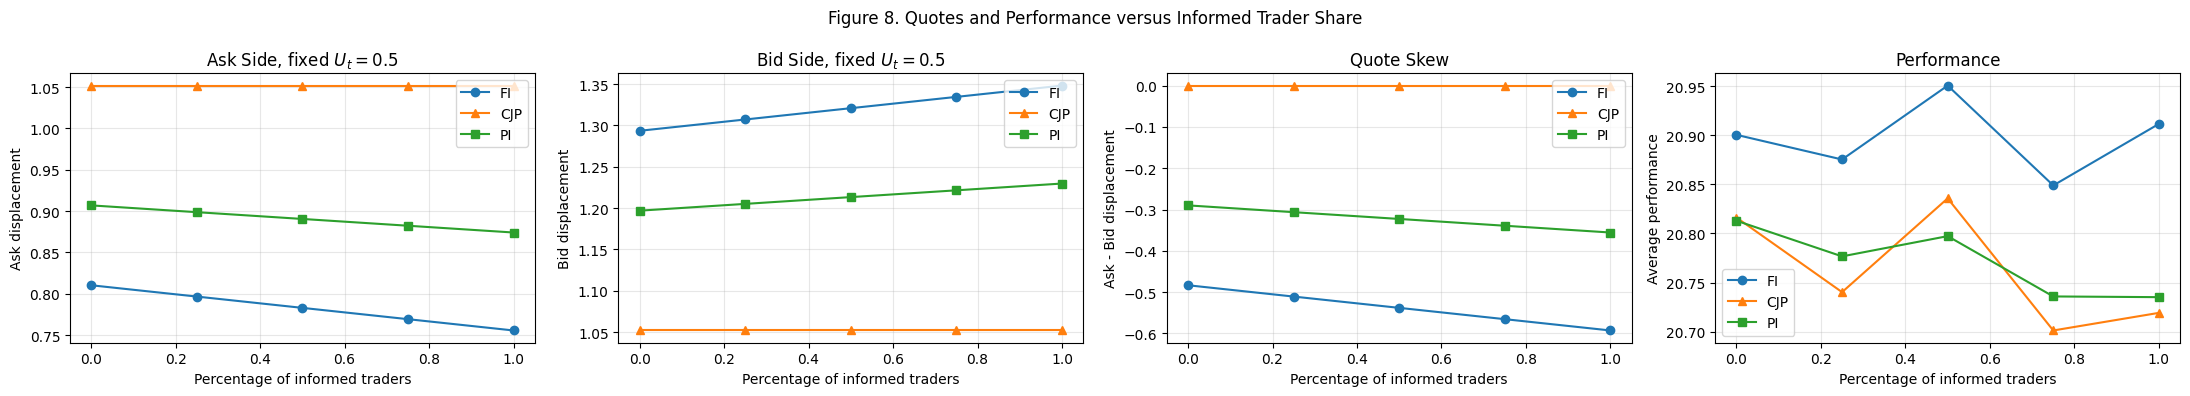

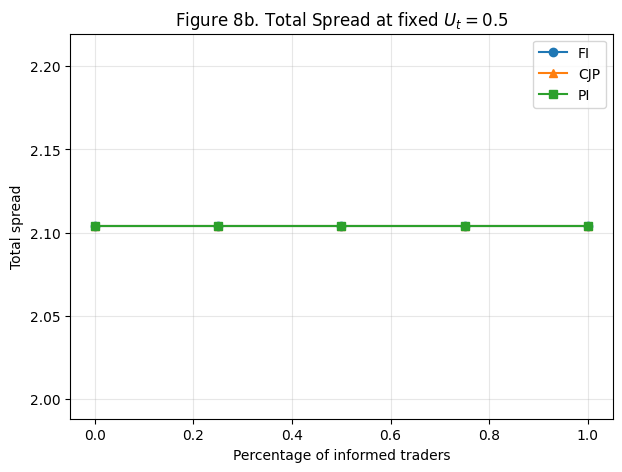

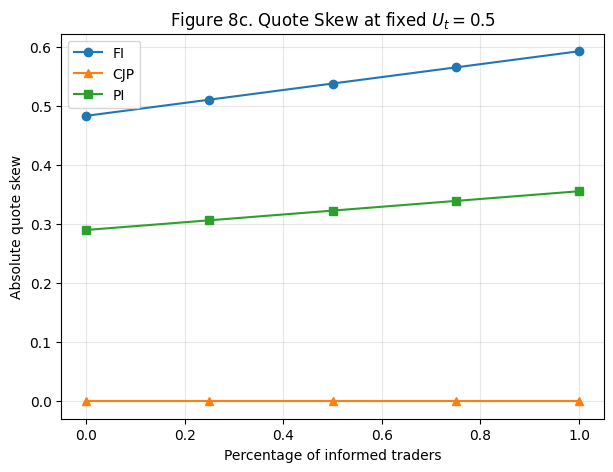

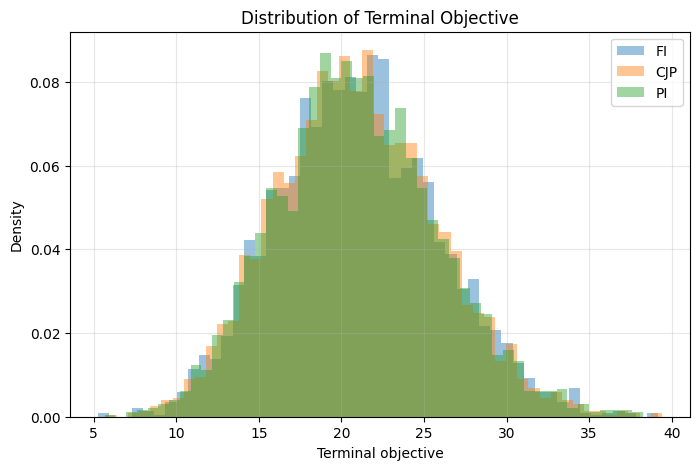


Saved files:
base_summary.csv
performance_vs_q.csv
performance_vs_gamma.csv
performance_vs_eta.csv
performance_vs_informed_share.csv
quotes_vs_informed_share_fixed_u.csv


In [3]:
# ============================================================
# 17. Figure 8: Informed Trader Share
# ============================================================

share_grid = [0.0, 0.25, 0.50, 0.75, 1.0]
share_rows = []
quote_rows = []

total_intensity = params["phi"] + params["psi"]

# fixed diagnostic state
t0 = 0.5
Q0 = 0.0
u_fixed = 0.5        # must be nonzero, otherwise informed-share effect disappears

for share in tqdm(share_grid, desc="informed-share-grid"):
    p_tmp = copy_params(
        params,
        phi=total_intensity * (1.0 - share),
        psi=total_intensity * share,
    )

    summary_tmp, _, _, coeff_tmp, _ = run_simulation(
        p_tmp,
        n_paths=2500,
        seed=4000 + int(1000 * share),
        show_progress=False
    )

    # performance unchanged
    for _, row in summary_tmp.iterrows():
        share_rows.append({
            "share": share,
            "strategy": row["strategy"],
            "mean_objective": row["mean_objective"],
            "std_objective": row["std_objective"],
            "mean_fills": row["mean_fills"],
            "mean_spread": row["mean_spread"],
        })

    # quote diagnostic: fix U_t, do not average over symmetric u-grid
    for strategy in ["FI", "CJP", "PI"]:
        if strategy == "FI":
            u_signal = u_fixed

        elif strategy == "CJP":
            u_signal = 0.0

        elif strategy == "PI":
            # PI observes filtered/attenuated fad, not full true U
            # simple diagnostic approximation
            u_signal = p_tmp["q_fad"] * u_fixed

        da, db = optimal_quotes(
            t=t0,
            Q=Q0,
            u_signal=u_signal,
            coeff_fun=coeff_tmp,
            p=p_tmp
        )

        quote_rows.append({
            "share": share,
            "strategy": strategy,
            "u_signal": u_signal,
            "ask_delta": da,
            "bid_delta": db,
            "total_spread": da + db,
            "quote_skew": da - db,
            "abs_quote_skew": abs(da - db),
        })

df_share = pd.DataFrame(share_rows)
df_quote = pd.DataFrame(quote_rows)

print("\nPerformance versus informed-trader share:")
print(df_share.pivot(index="share", columns="strategy", values="mean_objective").round(4))

print("\nAsk displacement at fixed U_t:")
print(df_quote.pivot(index="share", columns="strategy", values="ask_delta").round(4))

print("\nBid displacement at fixed U_t:")
print(df_quote.pivot(index="share", columns="strategy", values="bid_delta").round(4))

print("\nQuote skew = ask_delta - bid_delta:")
print(df_quote.pivot(index="share", columns="strategy", values="quote_skew").round(4))

print("\nTotal spread:")
print(df_quote.pivot(index="share", columns="strategy", values="total_spread").round(4))


fig, axes = plt.subplots(1, 4, figsize=(22, 4))

# Ask side
for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_quote[df_quote["strategy"] == strategy]
    axes[0].plot(sub["share"], sub["ask_delta"], marker=marker, label=strategy)

axes[0].set_xlabel("Percentage of informed traders")
axes[0].set_ylabel("Ask displacement")
axes[0].set_title(rf"Ask Side, fixed $U_t={u_fixed}$")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bid side
for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_quote[df_quote["strategy"] == strategy]
    axes[1].plot(sub["share"], sub["bid_delta"], marker=marker, label=strategy)

axes[1].set_xlabel("Percentage of informed traders")
axes[1].set_ylabel("Bid displacement")
axes[1].set_title(rf"Bid Side, fixed $U_t={u_fixed}$")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Quote skew
for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_quote[df_quote["strategy"] == strategy]
    axes[2].plot(sub["share"], sub["quote_skew"], marker=marker, label=strategy)

axes[2].set_xlabel("Percentage of informed traders")
axes[2].set_ylabel("Ask - Bid displacement")
axes[2].set_title("Quote Skew")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Performance unchanged
for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_share[df_share["strategy"] == strategy]
    axes[3].plot(sub["share"], sub["mean_objective"], marker=marker, label=strategy)

axes[3].set_xlabel("Percentage of informed traders")
axes[3].set_ylabel("Average performance")
axes[3].set_title("Performance")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.suptitle("Figure 8. Quotes and Performance versus Informed Trader Share")
plt.tight_layout()
plt.savefig("fig_informed_share.pdf", bbox_inches="tight")
plt.show()


# Optional: total spread figure
plt.figure(figsize=(7, 5))

for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_quote[df_quote["strategy"] == strategy]
    plt.plot(sub["share"], sub["total_spread"], marker=marker, label=strategy)

plt.xlabel("Percentage of informed traders")
plt.ylabel("Total spread")
plt.title(rf"Figure 8b. Total Spread at fixed $U_t={u_fixed}$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fig_informed_spread.pdf", bbox_inches="tight")
plt.show()


# Optional: absolute skew figure
plt.figure(figsize=(7, 5))

for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_quote[df_quote["strategy"] == strategy]
    plt.plot(sub["share"], sub["abs_quote_skew"], marker=marker, label=strategy)

plt.xlabel("Percentage of informed traders")
plt.ylabel("Absolute quote skew")
plt.title(rf"Figure 8c. Quote Skew at fixed $U_t={u_fixed}$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fig_informed_skew.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 18. Distribution Diagnostic
# ============================================================

plt.figure(figsize=(8, 5))
for strategy in ["FI", "CJP", "PI"]:
    vals = np.array([x["objective"] for x in results[strategy]])
    plt.hist(vals, bins=50, alpha=0.45, density=True, label=strategy)

plt.xlabel("Terminal objective")
plt.ylabel("Density")
plt.title("Distribution of Terminal Objective")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fig_histograms.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 19. Save Results
# ============================================================

summary.to_csv("base_summary.csv", index=False)
df_q.to_csv("performance_vs_q.csv", index=False)
df_gamma.to_csv("performance_vs_gamma.csv", index=False)
df_eta.to_csv("performance_vs_eta.csv", index=False)
df_share.to_csv("performance_vs_informed_share.csv", index=False)
df_quote.to_csv("quotes_vs_informed_share_fixed_u.csv", index=False)

print("\nSaved files:")
print("base_summary.csv")
print("performance_vs_q.csv")
print("performance_vs_gamma.csv")
print("performance_vs_eta.csv")
print("performance_vs_informed_share.csv")
print("quotes_vs_informed_share_fixed_u.csv")


1. Black-Scholes CallBS and Convexity Check

CallBS values with respect to K:
   K    CallBS
35.0 17.197658
36.0 16.363844
37.0 15.548963
38.0 14.754386
39.0 13.981371
40.0 13.231043
41.0 12.504385
42.0 11.802228
43.0 11.125247
44.0 10.473958
45.0  9.848721
46.0  9.249743
47.0  8.677084
48.0  8.130668
49.0  7.610290
50.0  7.115627
51.0  6.646253
52.0  6.201644
53.0  5.781197
54.0  5.384240
55.0  5.010039

Minimum second difference:
0.0189335757

Result: CallBS is numerically convex with respect to K.


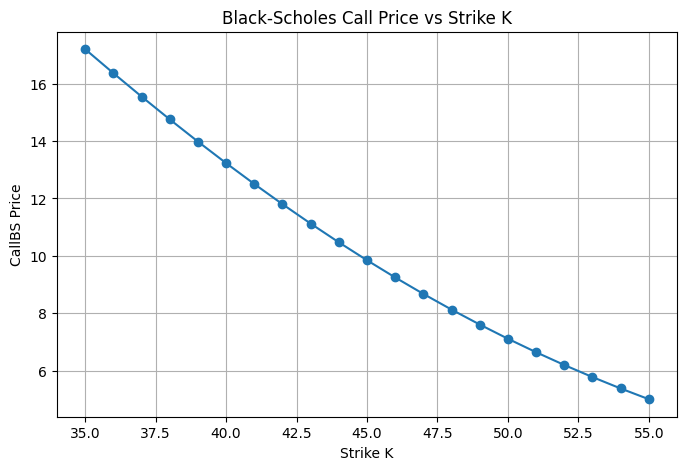


2. Asian Option Prices by Monte Carlo
   r  sigma  T  K  Asian_Arithmetic  Asian_Geometric
0.00    0.2  1 35         14.996263        14.834348
0.00    0.2  1 40         10.032366         9.880680
0.00    0.2  1 45          5.496747         5.358717
0.00    0.2  1 50          2.271281         2.188228
0.00    0.2  1 55          0.699636         0.660500
0.00    0.2  2 35         15.021189        14.688128
0.00    0.2  2 40         10.257704         9.988247
0.00    0.2  2 45          6.159738         5.937588
0.00    0.2  2 50          3.240404         3.068206
0.00    0.2  2 55          1.482775         1.349145
0.00    0.3  1 35         15.022862        14.689453
0.00    0.3  1 40         10.324859        10.005854
0.00    0.3  1 45          6.283111         6.078043
0.00    0.3  1 50          3.425476         3.233663
0.00    0.3  1 55          1.669079         1.511465
0.00    0.3  2 35         15.310025        14.593925
0.00    0.3  2 40         11.011532        10.458646
0.00   

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

# =========================================
# 1. Black-Scholes Call Price
# =========================================

def CallBS(S0, K, r, sigma, T):
    """
    Black-Scholes European call option price.
    """
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price


def check_convexity_in_K(S0=50, r=0.05, sigma=0.3, T=1):
    """
    Numerically check convexity of CallBS with respect to strike K.
    """
    K_grid = np.linspace(35, 55, 21)
    C_grid = np.array([CallBS(S0, K, r, sigma, T) for K in K_grid])

    second_diff = C_grid[:-2] - 2 * C_grid[1:-1] + C_grid[2:]

    df_convexity = pd.DataFrame({
        "K": K_grid,
        "CallBS": C_grid
    })

    is_convex = second_diff.min() >= -1e-10

    return df_convexity, second_diff.min(), is_convex


# =========================================
# 2. Simulate GBM Paths
# =========================================

def simulate_paths(S0, r, sigma, T, n_steps, M):
    """
    Simulate GBM paths under risk-neutral measure.
    """
    dt = T / n_steps
    Z = np.random.randn(M, n_steps)

    S = np.zeros((M, n_steps + 1))
    S[:, 0] = S0

    for t in range(1, n_steps + 1):
        S[:, t] = S[:, t - 1] * np.exp(
            (r - 0.5 * sigma**2) * dt
            + sigma * np.sqrt(dt) * Z[:, t - 1]
        )

    return S


# =========================================
# 3. Asian Option Monte Carlo Pricing
# =========================================

def asian_option_mc(S0, K, r, sigma, T, n_steps=50, M=20000, method="arithmetic"):
    """
    Monte Carlo Asian call option pricing.

    method:
        "arithmetic" or "geometric"
    """
    S = simulate_paths(S0, r, sigma, T, n_steps, M)

    if method == "arithmetic":
        A = np.mean(S, axis=1)
    elif method == "geometric":
        A = np.exp(np.mean(np.log(S), axis=1))
    else:
        raise ValueError("method must be 'arithmetic' or 'geometric'")

    payoff = np.maximum(A - K, 0)
    discounted_payoff = np.exp(-r * T) * payoff

    price = np.mean(discounted_payoff)
    std = np.std(discounted_payoff, ddof=1)

    return price, std, discounted_payoff


def confidence_interval(mean, std, M):
    """
    95% confidence interval.
    """
    z = 1.96
    half_width = z * std / np.sqrt(M)

    lower = mean - half_width
    upper = mean + half_width
    length = upper - lower

    return lower, upper, length


# =========================================
# 4. Run Full Experiment
# =========================================

def run_all_experiments():
    """
    Run Asian option pricing experiments for all required parameter values.
    """

    S0 = 50
    M = 200000
    n_steps = 50

    param_rows = [
        (0.00, [0.2, 0.3, 0.4]),
        (0.03, [0.2]),
        (0.04, [0.4]),
        (0.05, [0.3]),
        (1.00, [0.1]),
    ]

    K_list = [35, 40, 45, 50, 55]
    T_list = [1, 2]

    results = []

    for r, sigma_values in param_rows:
        for sigma in sigma_values:
            for T in T_list:
                for K in K_list:

                    price_a, std_a, _ = asian_option_mc(
                        S0=S0,
                        K=K,
                        r=r,
                        sigma=sigma,
                        T=T,
                        n_steps=n_steps,
                        M=M,
                        method="arithmetic"
                    )

                    ci_a_low, ci_a_high, ci_a_len = confidence_interval(
                        price_a, std_a, M
                    )

                    price_g, std_g, _ = asian_option_mc(
                        S0=S0,
                        K=K,
                        r=r,
                        sigma=sigma,
                        T=T,
                        n_steps=n_steps,
                        M=M,
                        method="geometric"
                    )

                    ci_g_low, ci_g_high, ci_g_len = confidence_interval(
                        price_g, std_g, M
                    )

                    bs_price = CallBS(S0, K, r, sigma, T)

                    results.append({
                        "r": r,
                        "sigma": sigma,
                        "T": T,
                        "K": K,

                        "Asian_Arithmetic": price_a,
                        "CI_A_low": ci_a_low,
                        "CI_A_high": ci_a_high,
                        "CI_A_length": ci_a_len,

                        "Asian_Geometric": price_g,
                        "CI_G_low": ci_g_low,
                        "CI_G_high": ci_g_high,
                        "CI_G_length": ci_g_len,

                        "BS_European": bs_price,

                        "BS_minus_Arithmetic": bs_price - price_a,
                        "Arithmetic_minus_Geometric": price_a - price_g
                    })

    return pd.DataFrame(results)


# =========================================
# 5. Display Results by Questions 1, 2, 3, 4
# =========================================

def display_question_outputs():
    """
    Print outputs corresponding to assignment questions 1, 2, 3, 4.
    """

    S0 = 50

    # -------------------------------------
    # Question 1
    # -------------------------------------
    print("\n" + "=" * 80)
    print("1. Black-Scholes CallBS and Convexity Check")
    print("=" * 80)

    df_convexity, min_second_diff, is_convex = check_convexity_in_K(
        S0=50,
        r=0.05,
        sigma=0.3,
        T=1
    )

    print("\nCallBS values with respect to K:")
    print(df_convexity.round(6).to_string(index=False))

    print("\nMinimum second difference:")
    print(round(min_second_diff, 10))

    if is_convex:
        print("\nResult: CallBS is numerically convex with respect to K.")
    else:
        print("\nResult: Convexity is not verified numerically.")

    plt.figure(figsize=(8, 5))
    plt.plot(df_convexity["K"], df_convexity["CallBS"], marker="o")
    plt.xlabel("Strike K")
    plt.ylabel("CallBS Price")
    plt.title("Black-Scholes Call Price vs Strike K")
    plt.grid(True)
    plt.show()

    # -------------------------------------
    # Questions 2, 3, 4
    # -------------------------------------
    df_results = run_all_experiments()

    # Question 2
    print("\n" + "=" * 80)
    print("2. Asian Option Prices by Monte Carlo")
    print("=" * 80)

    df_q2 = df_results[[
        "r", "sigma", "T", "K",
        "Asian_Arithmetic",
        "Asian_Geometric"
    ]]

    print(df_q2.round(6).to_string(index=False))

    # Question 3
    print("\n" + "=" * 80)
    print("3. 95% Confidence Intervals")
    print("=" * 80)

    df_q3 = df_results[[
        "r", "sigma", "T", "K",
        "Asian_Arithmetic",
        "CI_A_low",
        "CI_A_high",
        "CI_A_length",
        "Asian_Geometric",
        "CI_G_low",
        "CI_G_high",
        "CI_G_length"
    ]]

    print(df_q3.round(6).to_string(index=False))

    # Question 4
    print("\n" + "=" * 80)
    print("4. Compare Asian Option Prices with European CallBS")
    print("=" * 80)

    df_q4 = df_results[[
        "r", "sigma", "T", "K",
        "Asian_Arithmetic",
        "Asian_Geometric",
        "BS_European",
        "BS_minus_Arithmetic",
        "Arithmetic_minus_Geometric"
    ]]

    print(df_q4.round(6).to_string(index=False))

    print("\nSummary:")
    print("Usually, Geometric Asian <= Arithmetic Asian <= European CallBS.")
    print("The European call is usually more expensive because it depends on S_T,")
    print("while the Asian option depends on an average price, which reduces volatility.")

    return df_results


df_results = display_question_outputs()

df_results.to_csv("asian_option_results.csv", index=False)

print("\nSaved results to asian_option_results.csv")

Monte Carlo:   0%|          | 0/3000 [00:00<?, ?it/s]


Base Simulation Summary:
  strategy  mean_objective  std_objective      p05      p50      p95  \
0       FI         21.0377         4.9049  13.4818  20.8704  29.4252   
1      CJP         20.9469         4.8772  13.2456  20.7405  29.1156   
2       PI         20.9653         4.9012  13.3515  20.7359  29.3468   

   mean_fills  mean_spread  
0     21.5867       2.1148  
1     21.6287       2.1148  
2     21.6193       2.1148  


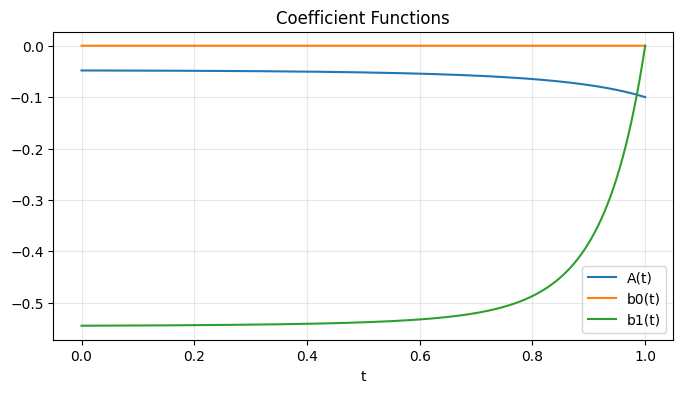

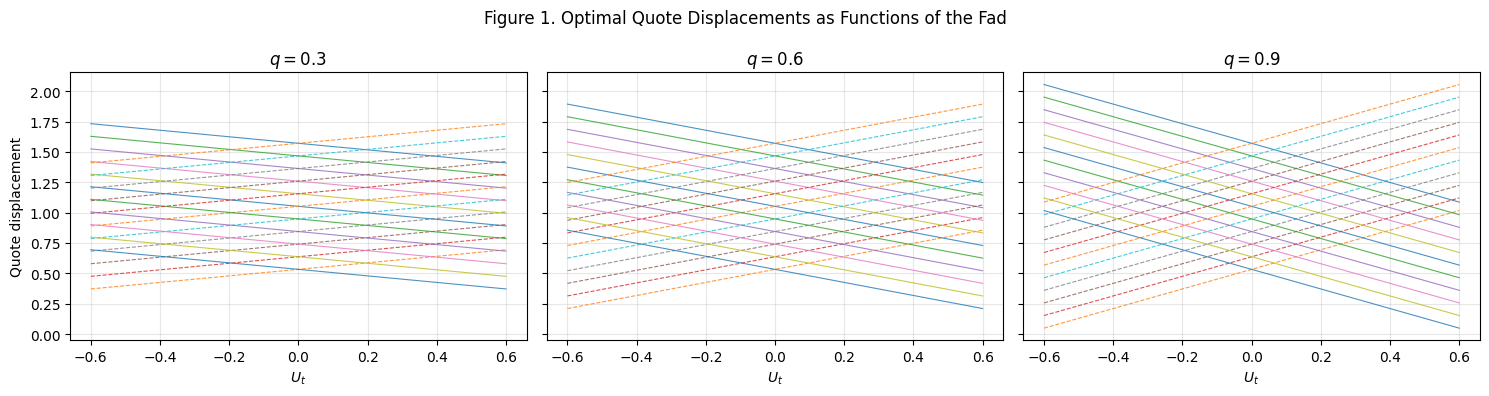

c:\Users\Zack66Fair\miniconda3\envs\torch310_mini\lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Zack66Fair\miniconda3\envs\torch310_mini\lib\site-packages\numpy\_core\_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


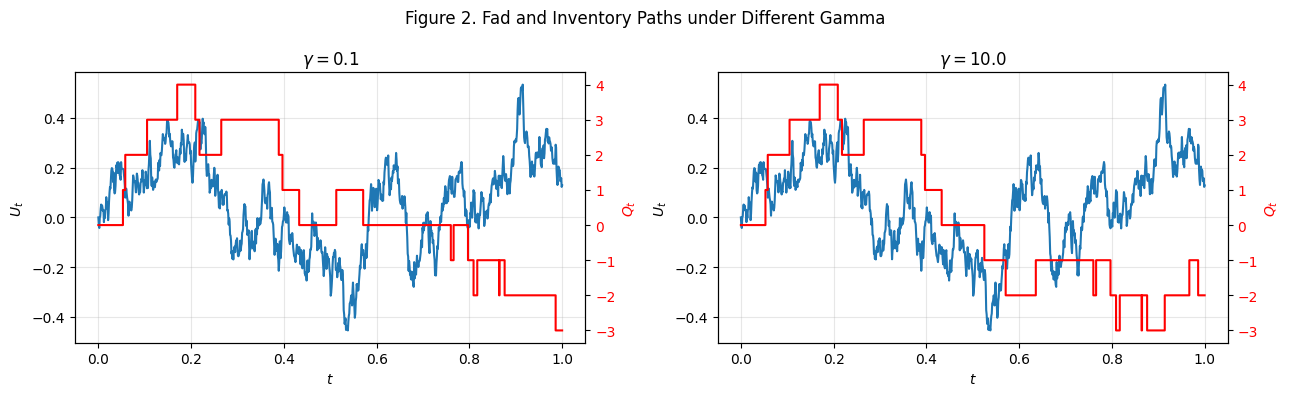

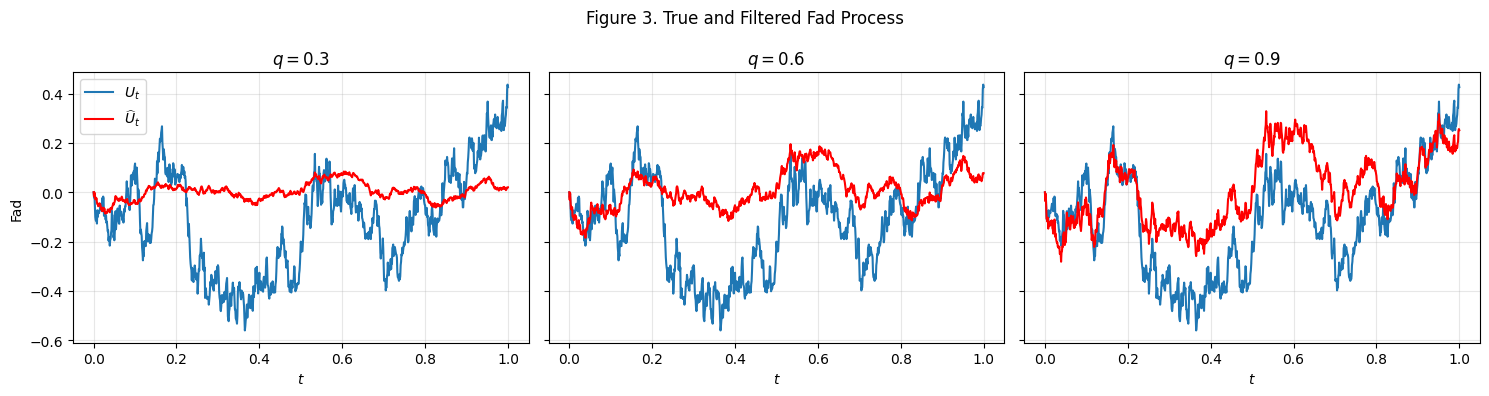

q-grid:   0%|          | 0/6 [00:00<?, ?it/s]


Performance versus q:
strategy      CJP       FI       PI
q                                  
0.0       20.7717  20.7717  20.7717
0.2       20.9336  20.9760  20.9379
0.4       20.9530  20.9675  20.9411
0.6       20.8079  20.9593  20.8266
0.8       20.8280  21.0663  20.8895
1.0       20.6376  21.0238  21.0238


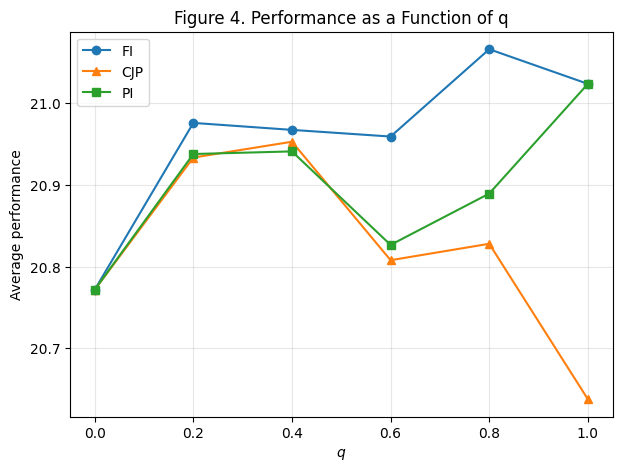

gamma-grid:   0%|          | 0/4 [00:00<?, ?it/s]


Performance versus gamma, with psi rescaled:
strategy      CJP       FI       PI
gamma                              
0.0       20.8889  21.0153  20.8823
1.0       20.7755  20.9049  20.7633
2.0       20.6622  20.8614  20.7074
3.0       20.3156  20.5570  20.3466

Rescaled psi values:
   gamma   phi  psi_rescaled
0    0.0  15.0     15.135609
3    1.0  15.0     15.000000
6    2.0  15.0     14.600419
9    3.0  15.0     13.957963


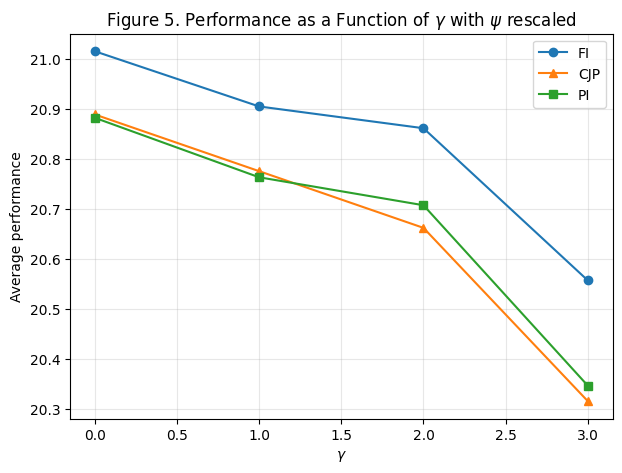

eta-grid:   0%|          | 0/5 [00:00<?, ?it/s]


Performance versus eta, with psi rescaled:
strategy      CJP       FI       PI
eta                                
2.5       20.3889  20.6652  20.4531
5.0       20.6098  20.7557  20.6406
7.5       21.0434  21.2408  21.0608
10.0      20.7477  20.8467  20.7572
12.5      20.7376  20.8734  20.7437

Rescaled psi values:
     eta   phi  psi_rescaled
0    2.5  15.0     14.600419
3    5.0  15.0     14.865606
6    7.5  15.0     14.955067
9   10.0  15.0     15.000000
12  12.5  15.0     15.027024


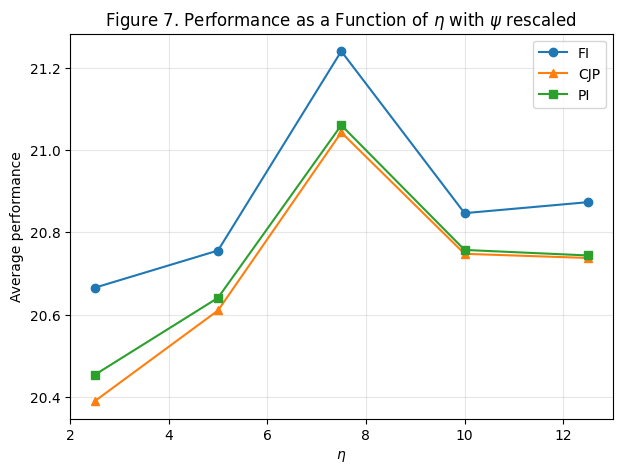

informed-share-grid:   0%|          | 0/5 [00:00<?, ?it/s]


Performance versus informed-trader share:
strategy      CJP       FI       PI
share                              
0.00      20.8162  20.9004  20.8129
0.25      20.7402  20.8753  20.7766
0.50      20.8357  20.9506  20.7973
0.75      20.7012  20.8489  20.7358
1.00      20.7191  20.9116  20.7351

Ask displacement at fixed U_t:
strategy     CJP      FI      PI
share                           
0.00      1.0519  0.8103  0.9069
0.25      1.0519  0.7966  0.8987
0.50      1.0519  0.7829  0.8905
0.75      1.0519  0.7692  0.8823
1.00      1.0519  0.7555  0.8741

Bid displacement at fixed U_t:
strategy     CJP      FI      PI
share                           
0.00      1.0519  1.2936  1.1969
0.25      1.0519  1.3072  1.2051
0.50      1.0519  1.3209  1.2133
0.75      1.0519  1.3346  1.2215
1.00      1.0519  1.3483  1.2297

Quote skew = ask_delta - bid_delta:
strategy  CJP      FI      PI
share                        
0.00      0.0 -0.4833 -0.2900
0.25      0.0 -0.5107 -0.3064
0.50      0.0 -0.5380 

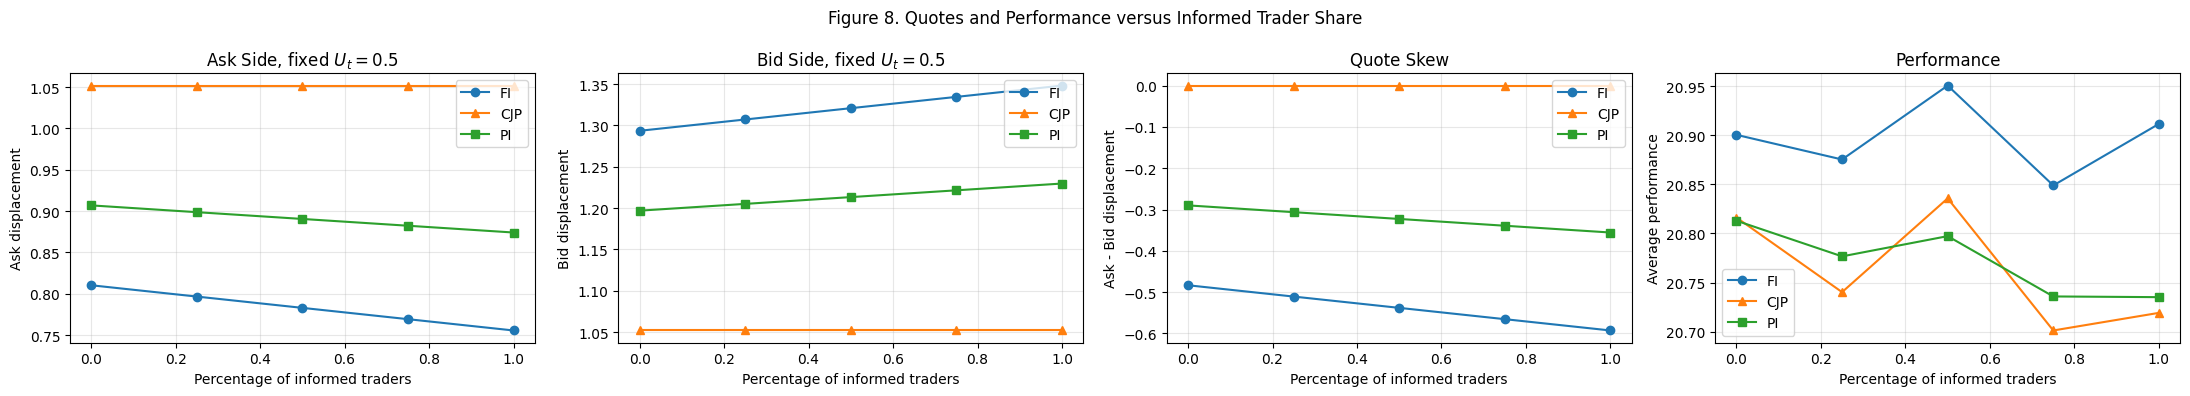

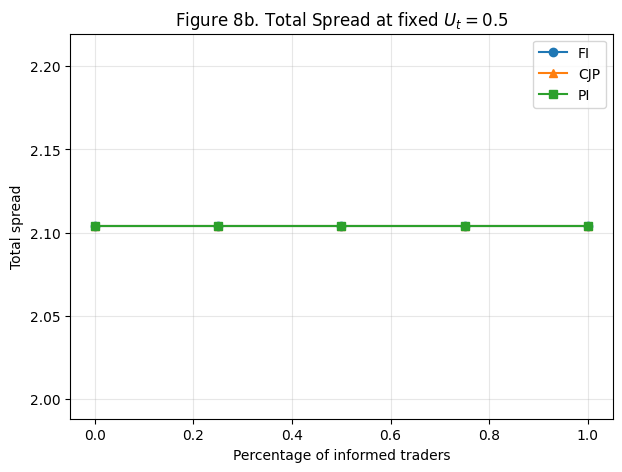

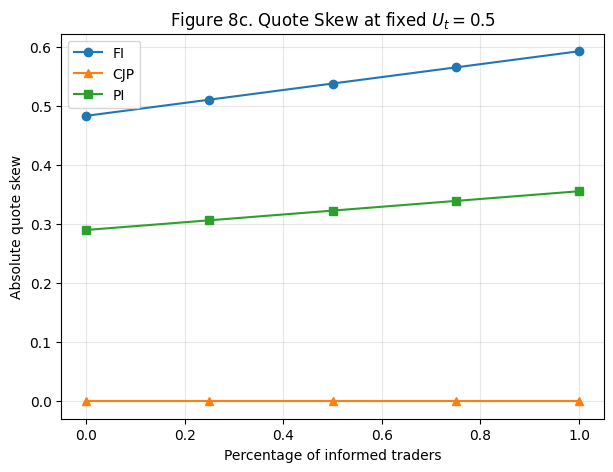

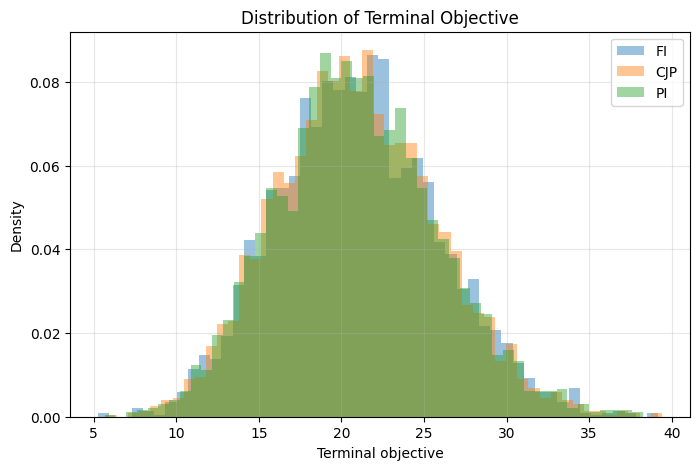

In [2]:
# ============================================================
# Market Making with Fads, Informed and Uninformed Traders
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from tqdm.auto import tqdm

np.random.seed(42)

# ============================================================
# 1. Parameters
# ============================================================

params = {
    "T": 1.0,
    "N": 1000,
    "n_paths": 3000,

    # price and fad
    "mu": 0.0,
    "sigma": 1.0,
    "eta": 10.0,
    "q_fad": 0.6,

    # market order arrival parameters
    "phi": 15.0,
    "psi": 15.0,

    # quote intensity decay
    "k": 1.0,

    # informed sensitivity
    "gamma": 1.0,

    # inventory penalties
    "alpha": 0.1,
    "varphi": 0.1,

    # inventory bounds
    "q_lower": -10,
    "q_upper": 10,

    # lower quote displacement bound
    "delta_a_inf": 5.0,
    "delta_b_inf": 5.0,

    # initial values
    "S0": 100.0,
    "Q0": 0.0,
    "X0": 0.0,
}

# ============================================================
# 2. Utility
# ============================================================

def copy_params(base, **kwargs):
    p = base.copy()
    p.update(kwargs)
    q = p["q_fad"]
    p["p_noise"] = np.sqrt(max(1.0 - q**2, 0.0))
    return p


def lambda_ask(delta_a, u_true, q_inventory, p):
    if q_inventory <= p["q_lower"] or not np.isfinite(delta_a):
        return 0.0

    toxic = p["sigma"] * p["q_fad"] * u_true
    intensity = (
        p["phi"] + p["psi"] * np.exp(-p["gamma"] * toxic)
    ) * np.exp(-p["k"] * delta_a)

    return max(float(intensity), 0.0)


def lambda_bid(delta_b, u_true, q_inventory, p):
    if q_inventory >= p["q_upper"] or not np.isfinite(delta_b):
        return 0.0

    toxic = p["sigma"] * p["q_fad"] * u_true
    intensity = (
        p["phi"] + p["psi"] * np.exp(p["gamma"] * toxic)
    ) * np.exp(-p["k"] * delta_b)

    return max(float(intensity), 0.0)


# ============================================================
# 3. Solve A(t), b0(t), b1(t)
# ============================================================

def terminal_zero_linear_solution(t_grid, a_grid, c_grid):
    """
    Solve y'(t) + a(t)y(t) + c(t) = 0, y(T)=0.

    Solution:
        y(t) = integral_t^T c(s) exp(-int_t^s a(r)dr) ds
    """
    A_int = cumulative_trapezoid(a_grid, t_grid, initial=0.0)

    h = np.exp(A_int) * c_grid

    rev_int = cumulative_trapezoid(h[::-1], t_grid[::-1], initial=0.0)
    right_int = -rev_int[::-1]

    y_grid = np.exp(-A_int) * right_int
    return y_grid


def solve_coefficients(p):
    T = p["T"]
    k = p["k"]
    phi = p["phi"]
    psi = p["psi"]
    varphi = p["varphi"]
    alpha = p["alpha"]
    mu = p["mu"]
    eta = p["eta"]
    sigma = p["sigma"]
    rho = p["q_fad"]
    gamma = p["gamma"]

    kappa = 4.0 * (phi + psi) * np.exp(-1.0) * k

    t_grid = np.linspace(0.0, T, 5000)

    beta_A = np.sqrt(varphi / kappa)
    r = np.sqrt(varphi * kappa)

    if not np.isclose(np.sqrt(varphi), np.sqrt(kappa) * alpha):
        z = ((beta_A - alpha) / (beta_A + alpha)) * np.exp(2.0 * r * (t_grid - T))
        A_grid = beta_A * (z - 1.0) / (z + 1.0)
    else:
        A_grid = -alpha * np.ones_like(t_grid)

    # b0 ODE:
    # 0 = b0' + mu + kappa A b0
    a0_grid = kappa * A_grid
    c0_grid = mu * np.ones_like(t_grid)
    b0_grid = terminal_zero_linear_solution(t_grid, a0_grid, c0_grid)

    # b1 ODE:
    # 0 = b1' - eta*sigma*rho - eta*b1
    #     + kappa*A*b1
    #     + 4e^-1 psi rho sigma gamma A
    #     + 4e^-1 k gamma rho sigma psi A^2
    a1_grid = -eta + kappa * A_grid

    c1_grid = (
        -eta * sigma * rho
        + 4.0 * np.exp(-1.0) * psi * rho * sigma * gamma * A_grid
        + 4.0 * np.exp(-1.0) * k * gamma * rho * sigma * psi * A_grid**2
    )

    b1_grid = terminal_zero_linear_solution(t_grid, a1_grid, c1_grid)

    def coeff_fun(t):
        t_arr = np.asarray(t)
        A = np.interp(t_arr, t_grid, A_grid)
        b0 = np.interp(t_arr, t_grid, b0_grid)
        b1 = np.interp(t_arr, t_grid, b1_grid)
        return np.array([A, b0, b1])

    return coeff_fun, {
        "t_grid": t_grid,
        "A": A_grid,
        "b0": b0_grid,
        "b1": b1_grid,
        "kappa": kappa,
    }


def get_coeffs(t, coeff_fun):
    A, b0, b1 = coeff_fun(t)
    return float(A), float(b0), float(b1)


# ============================================================
# 4. Quote Rules
# FI: full information, uses true U
# CJP: ignores fad, uses u = 0
# PI: partial information, uses U_hat
# ============================================================

def optimal_quotes(t, Q, u_signal, coeff_fun, p):
    A, b0, b1 = get_coeffs(t, coeff_fun)

    B = b0 + u_signal * b1

    delta_minus_V = (-2.0 * Q + 1.0) * A - B
    delta_plus_V = (2.0 * Q + 1.0) * A + B

    delta_a = 1.0 / p["k"] - delta_minus_V
    delta_b = 1.0 / p["k"] - delta_plus_V

    delta_a = max(delta_a, -p["delta_a_inf"])
    delta_b = max(delta_b, -p["delta_b_inf"])

    if Q <= p["q_lower"]:
        delta_a = np.inf

    if Q >= p["q_upper"]:
        delta_b = np.inf

    return float(delta_a), float(delta_b)


# ============================================================
# 5. Exogenous Shocks
# ============================================================

def generate_shocks(p, rng):
    N = p["N"]
    dt = p["T"] / p["N"]

    return {
        "dB": np.sqrt(dt) * rng.standard_normal(N),
        "dZ": np.sqrt(dt) * rng.standard_normal(N),
        "Ua": rng.random(N),
        "Ub": rng.random(N),
    }


# ============================================================
# 6. Exact Riccati + Kalman-Bucy Filter
# ============================================================

def update_filter(U_hat, P_hat, dS, p, dt):
    """
    Continuous-time Kalman-Bucy filter discretized by Euler.

    Model:
        dU_t = -eta U_t dt + dB_t
        dS_t = (mu - eta sigma rho U_t)dt + sigma dI_t

    Innovation:
        dI_t = dS_t - (mu - eta sigma rho U_hat_t)dt

    Filter:
        dU_hat_t = -eta U_hat_t dt
                   + sigma^{-1}(rho - eta rho P_hat_t)dI_t

    Riccati:
        dP_hat_t/dt =
            - eta^2 rho^2 P_hat_t^2
            - P_hat_t(2 eta - 2 eta rho^2)
            + (1 - rho^2)
    """
    mu = p["mu"]
    sigma = p["sigma"]
    eta = p["eta"]
    rho = p["q_fad"]
    p_noise2 = max(1.0 - rho**2, 0.0)

    dI = dS - (mu - eta * sigma * rho * U_hat) * dt

    K = (rho - eta * rho * P_hat) / max(sigma, 1e-12)

    U_hat_new = U_hat - eta * U_hat * dt + K * dI

    dP = (
        -eta**2 * rho**2 * P_hat**2
        - P_hat * (2.0 * eta - 2.0 * eta * rho**2)
        + p_noise2
    ) * dt

    P_hat_new = max(P_hat + dP, 0.0)

    return float(U_hat_new), float(P_hat_new)


# ============================================================
# 7. Simulate One Path
# ============================================================

def simulate_one_path(p, coeff_fun, shocks, strategy):
    T = p["T"]
    N = p["N"]
    dt = T / N

    mu = p["mu"]
    sigma = p["sigma"]
    eta = p["eta"]
    rho = p["q_fad"]
    p_noise = p["p_noise"]

    S = np.zeros(N + 1)
    U = np.zeros(N + 1)
    U_hat = np.zeros(N + 1)
    P_hat = np.zeros(N + 1)
    Q = np.zeros(N + 1)
    X = np.zeros(N + 1)

    delta_a_arr = np.full(N, np.nan)
    delta_b_arr = np.full(N, np.nan)
    lambda_a_arr = np.zeros(N)
    lambda_b_arr = np.zeros(N)

    S[0] = p["S0"]
    Q[0] = p["Q0"]
    X[0] = p["X0"]

    fill_a_count = 0
    fill_b_count = 0

    for i in range(N):
        t = i * dt

        dB = shocks["dB"][i]
        dZ = shocks["dZ"][i]

        # OU fad
        dU = -eta * U[i] * dt + dB
        U[i + 1] = U[i] + dU

        # price process
        dS = mu * dt + sigma * (rho * dU + p_noise * dZ)
        S[i + 1] = S[i] + dS

        # exact partial-information filter
        U_hat[i + 1], P_hat[i + 1] = update_filter(U_hat[i], P_hat[i], dS, p, dt)

        if strategy == "FI":
            u_signal = U[i]
        elif strategy == "CJP":
            u_signal = 0.0
        elif strategy == "PI":
            u_signal = U_hat[i]
        else:
            raise ValueError("strategy must be FI, CJP, or PI")

        delta_a, delta_b = optimal_quotes(t, Q[i], u_signal, coeff_fun, p)

        delta_a_arr[i] = delta_a if np.isfinite(delta_a) else np.nan
        delta_b_arr[i] = delta_b if np.isfinite(delta_b) else np.nan

        lam_a = lambda_ask(delta_a, U[i], Q[i], p)
        lam_b = lambda_bid(delta_b, U[i], Q[i], p)

        lambda_a_arr[i] = lam_a
        lambda_b_arr[i] = lam_b

        prob_a = min(lam_a * dt, 1.0)
        prob_b = min(lam_b * dt, 1.0)

        dNa = shocks["Ua"][i] < prob_a
        dNb = shocks["Ub"][i] < prob_b

        X[i + 1] = X[i]
        Q[i + 1] = Q[i]

        if dNa:
            X[i + 1] += S[i] + delta_a
            Q[i + 1] -= 1.0
            fill_a_count += 1

        if dNb:
            X[i + 1] -= S[i] - delta_b
            Q[i + 1] += 1.0
            fill_b_count += 1

    terminal_objective = (
        X[-1]
        + Q[-1] * S[-1]
        - p["alpha"] * Q[-1] ** 2
        - p["varphi"] * np.sum(Q[:-1] ** 2) * dt
    )

    avg_spread = np.nanmean(delta_a_arr + delta_b_arr)

    return {
        "S": S,
        "U": U,
        "U_hat": U_hat,
        "P_hat": P_hat,
        "Q": Q,
        "X": X,
        "delta_a": delta_a_arr,
        "delta_b": delta_b_arr,
        "lambda_a": lambda_a_arr,
        "lambda_b": lambda_b_arr,
        "objective": terminal_objective,
        "avg_spread": avg_spread,
        "n_fills": fill_a_count + fill_b_count,
    }


# ============================================================
# 8. Monte Carlo Runner
# ============================================================

def summarize_results(results):
    rows = []

    for strategy, outs in results.items():
        obj = np.array([x["objective"] for x in outs])
        fills = np.array([x["n_fills"] for x in outs])
        spreads = np.array([x["avg_spread"] for x in outs])

        rows.append({
            "strategy": strategy,
            "mean_objective": obj.mean(),
            "std_objective": obj.std(ddof=1),
            "p05": np.quantile(obj, 0.05),
            "p50": np.quantile(obj, 0.50),
            "p95": np.quantile(obj, 0.95),
            "mean_fills": fills.mean(),
            "mean_spread": spreads.mean(),
        })

    return pd.DataFrame(rows)


def run_simulation(p, n_paths=None, seed=42, show_progress=True):
    p = copy_params(p)

    if n_paths is not None:
        p["n_paths"] = n_paths

    coeff_fun, coeff_data = solve_coefficients(p)

    strategies = ["FI", "CJP", "PI"]
    results = {s: [] for s in strategies}
    sample_paths = {}

    rng = np.random.default_rng(seed)

    iterator = range(p["n_paths"])
    if show_progress:
        iterator = tqdm(iterator, desc="Monte Carlo")

    for m in iterator:
        shocks = generate_shocks(p, rng)

        for strategy in strategies:
            out = simulate_one_path(p, coeff_fun, shocks, strategy)
            results[strategy].append(out)

            if m == 0:
                sample_paths[strategy] = out

    summary = summarize_results(results)
    return summary, results, sample_paths, coeff_fun, coeff_data


# ============================================================
# 9. Base Simulation
# ============================================================

summary, results, sample_paths, coeff_fun, coeff_data = run_simulation(
    params,
    n_paths=params["n_paths"],
    seed=42,
    show_progress=True
)

print("\nBase Simulation Summary:")
print(summary.round(4))


# ============================================================
# 10. Diagnostic: Coefficients
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(coeff_data["t_grid"], coeff_data["A"], label="A(t)")
plt.plot(coeff_data["t_grid"], coeff_data["b0"], label="b0(t)")
plt.plot(coeff_data["t_grid"], coeff_data["b1"], label="b1(t)")
plt.xlabel("t")
plt.title("Coefficient Functions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fig_coefficients.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 11. Figure 1: Quote Displacements as Functions of Fad
# ============================================================

u_grid = np.linspace(-0.6, 0.6, 150)
inventory_grid = np.arange(-5, 6, 1)
q_grid = [0.3, 0.6, 0.9]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, qval in zip(axes, q_grid):
    p_tmp = copy_params(params, q_fad=qval)
    coeff_tmp, _ = solve_coefficients(p_tmp)

    for Q0 in inventory_grid:
        da_vals, db_vals = [], []

        for u in u_grid:
            da, db = optimal_quotes(0.5, Q0, u, coeff_tmp, p_tmp)
            da_vals.append(da)
            db_vals.append(db)

        ax.plot(u_grid, da_vals, linewidth=0.8, alpha=0.8)
        ax.plot(u_grid, db_vals, linestyle="--", linewidth=0.8, alpha=0.8)

    ax.set_title(rf"$q={qval}$")
    ax.set_xlabel(r"$U_t$")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Quote displacement")
plt.suptitle("Figure 1. Optimal Quote Displacements as Functions of the Fad")
plt.tight_layout()
plt.savefig("fig_displacements.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 12. Figure 2: Fad and Inventory Paths under Different Gamma
# ============================================================

gamma_grid = [0.1, 10.0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

for ax, gamma_val in zip(axes, gamma_grid):
    p_tmp = copy_params(params, gamma=gamma_val, q_fad=0.6)
    summary_tmp, results_tmp, sample_tmp, coeff_tmp, _ = run_simulation(
        p_tmp,
        n_paths=1,
        seed=123,
        show_progress=False
    )

    sample = sample_tmp["FI"]
    time_grid = np.linspace(0, p_tmp["T"], p_tmp["N"] + 1)

    ax.plot(time_grid, sample["U"], label=r"$U_t$")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$U_t$")
    ax.grid(True, alpha=0.3)

    ax2 = ax.twinx()
    ax2.step(time_grid, sample["Q"], where="post", color="red", label=r"$Q_t$")
    ax2.set_ylabel(r"$Q_t$", color="red")
    ax2.tick_params(axis="y", labelcolor="red")

    ax.set_title(rf"$\gamma={gamma_val}$")

plt.suptitle("Figure 2. Fad and Inventory Paths under Different Gamma")
plt.tight_layout()
plt.savefig("fig_gamma_paths.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 13. Figure 3: True and Filtered Fad
# ============================================================

q_grid = [0.3, 0.6, 0.9]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, qval in zip(axes, q_grid):
    p_tmp = copy_params(params, q_fad=qval)
    summary_tmp, results_tmp, sample_tmp, coeff_tmp, _ = run_simulation(
        p_tmp,
        n_paths=1,
        seed=321,
        show_progress=False
    )

    sample = sample_tmp["PI"]
    time_grid = np.linspace(0, p_tmp["T"], p_tmp["N"] + 1)

    ax.plot(time_grid, sample["U"], label=r"$U_t$")
    ax.plot(time_grid, sample["U_hat"], label=r"$\widehat U_t$", color="red")
    ax.set_title(rf"$q={qval}$")
    ax.set_xlabel(r"$t$")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Fad")
axes[0].legend()
plt.suptitle("Figure 3. True and Filtered Fad Process")
plt.tight_layout()
plt.savefig("fig_filter.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 14. Figure 4 / Table: Performance versus q
# ============================================================

q_perf_grid = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
q_rows = []

for qval in tqdm(q_perf_grid, desc="q-grid"):
    p_tmp = copy_params(params, q_fad=qval)
    summary_tmp, _, _, _, _ = run_simulation(
        p_tmp,
        n_paths=2500,
        seed=1000 + int(1000 * qval),
        show_progress=False
    )

    for _, row in summary_tmp.iterrows():
        q_rows.append({
            "q": qval,
            "strategy": row["strategy"],
            "mean_objective": row["mean_objective"],
            "std_objective": row["std_objective"],
            "mean_fills": row["mean_fills"],
            "mean_spread": row["mean_spread"],
        })

df_q = pd.DataFrame(q_rows)

print("\nPerformance versus q:")
print(df_q.pivot(index="q", columns="strategy", values="mean_objective").round(4))

plt.figure(figsize=(7, 5))
for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_q[df_q["strategy"] == strategy]
    plt.plot(sub["q"], sub["mean_objective"], marker=marker, label=strategy)

plt.xlabel(r"$q$")
plt.ylabel("Average performance")
plt.title("Figure 4. Performance as a Function of q")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fig_perf_q.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 15. Figure 5 / Table: Performance versus gamma
#     Paper-style: rescale psi when gamma changes
# ============================================================

def psi_rescaled_for_gamma(base_p, gamma_new, gamma_ref=None):
    """
    Rescale psi so that expected informed market arrivals stay constant
    when gamma changes.

    For OU: dU = -eta U dt + dB,
    stationary Var(U) = 1 / (2 eta).

    toxic = sigma * q_fad * U

    E[exp(gamma * toxic)]
    = exp(0.5 * gamma^2 * sigma^2 * q_fad^2 * Var(U)).
    """
    if gamma_ref is None:
        gamma_ref = base_p["gamma"]

    sigma = base_p["sigma"]
    rho = base_p["q_fad"]
    eta = base_p["eta"]

    var_U = 1.0 / (2.0 * eta)

    m_ref = np.exp(0.5 * (gamma_ref * sigma * rho) ** 2 * var_U)
    m_new = np.exp(0.5 * (gamma_new * sigma * rho) ** 2 * var_U)

    return base_p["psi"] * m_ref / m_new


gamma_grid = [0.0, 1.0, 2.0, 3.0]
gamma_rows = []

for gamma_val in tqdm(gamma_grid, desc="gamma-grid"):
    psi_gamma = psi_rescaled_for_gamma(
        params,
        gamma_new=gamma_val,
        gamma_ref=params["gamma"]
    )

    p_tmp = copy_params(
        params,
        gamma=gamma_val,
        psi=psi_gamma
    )

    summary_tmp, _, _, _, _ = run_simulation(
        p_tmp,
        n_paths=2500,
        seed=2000 + int(100 * gamma_val),
        show_progress=False
    )

    for _, row in summary_tmp.iterrows():
        gamma_rows.append({
            "gamma": gamma_val,
            "psi_rescaled": psi_gamma,
            "phi": p_tmp["phi"],
            "strategy": row["strategy"],
            "mean_objective": row["mean_objective"],
            "std_objective": row["std_objective"],
            "mean_fills": row["mean_fills"],
            "mean_spread": row["mean_spread"],
        })

df_gamma = pd.DataFrame(gamma_rows)

print("\nPerformance versus gamma, with psi rescaled:")
print(df_gamma.pivot(index="gamma", columns="strategy", values="mean_objective").round(4))

print("\nRescaled psi values:")
print(
    df_gamma
    .drop_duplicates("gamma")[["gamma", "phi", "psi_rescaled"]]
    .round(6)
)

plt.figure(figsize=(7, 5))

for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_gamma[df_gamma["strategy"] == strategy]
    plt.plot(
        sub["gamma"],
        sub["mean_objective"],
        marker=marker,
        label=strategy
    )

plt.xlabel(r"$\gamma$")
plt.ylabel("Average performance")
plt.title(r"Figure 5. Performance as a Function of $\gamma$ with $\psi$ rescaled")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fig_perf_gamma.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 16. Figure 7 / Table: Performance versus eta
#     Paper-style: rescale psi when eta changes
# ============================================================

def psi_rescaled_for_eta(base_p, eta_new, eta_ref=None):
    """
    Rescale psi so that expected informed market arrivals stay comparable
    when eta changes.

    For OU:
        dU = -eta U dt + dB

    Stationary variance:
        Var(U) = 1 / (2 eta)

    toxic = sigma * q_fad * U

    E[exp(gamma * toxic)]
    = exp(0.5 * gamma^2 * sigma^2 * q_fad^2 * Var(U)).
    """
    if eta_ref is None:
        eta_ref = base_p["eta"]

    gamma = base_p["gamma"]
    sigma = base_p["sigma"]
    rho = base_p["q_fad"]

    var_ref = 1.0 / (2.0 * eta_ref)
    var_new = 1.0 / (2.0 * eta_new)

    m_ref = np.exp(0.5 * (gamma * sigma * rho) ** 2 * var_ref)
    m_new = np.exp(0.5 * (gamma * sigma * rho) ** 2 * var_new)

    return base_p["psi"] * m_ref / m_new


eta_grid = [2.5, 5.0, 7.5, 10.0, 12.5]
eta_rows = []

for eta_val in tqdm(eta_grid, desc="eta-grid"):
    psi_eta = psi_rescaled_for_eta(
        params,
        eta_new=eta_val,
        eta_ref=params["eta"]
    )

    p_tmp = copy_params(
        params,
        eta=eta_val,
        psi=psi_eta
    )

    summary_tmp, _, _, _, _ = run_simulation(
        p_tmp,
        n_paths=2500,
        seed=3000 + int(100 * eta_val),
        show_progress=False
    )

    for _, row in summary_tmp.iterrows():
        eta_rows.append({
            "eta": eta_val,
            "psi_rescaled": psi_eta,
            "phi": p_tmp["phi"],
            "strategy": row["strategy"],
            "mean_objective": row["mean_objective"],
            "std_objective": row["std_objective"],
            "mean_fills": row["mean_fills"],
            "mean_spread": row["mean_spread"],
        })

df_eta = pd.DataFrame(eta_rows)

print("\nPerformance versus eta, with psi rescaled:")
print(df_eta.pivot(index="eta", columns="strategy", values="mean_objective").round(4))

print("\nRescaled psi values:")
print(
    df_eta
    .drop_duplicates("eta")[["eta", "phi", "psi_rescaled"]]
    .round(6)
)

plt.figure(figsize=(7, 5))

for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_eta[df_eta["strategy"] == strategy]
    plt.plot(
        sub["eta"],
        sub["mean_objective"],
        marker=marker,
        label=strategy
    )

plt.xlabel(r"$\eta$")
plt.ylabel("Average performance")
plt.title(r"Figure 7. Performance as a Function of $\eta$ with $\psi$ rescaled")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fig_perf_eta.pdf", bbox_inches="tight")
plt.show()

# ============================================================
# 17. Figure 8: Informed Trader Share
# ============================================================

share_grid = [0.0, 0.25, 0.50, 0.75, 1.0]
share_rows = []
quote_rows = []

total_intensity = params["phi"] + params["psi"]

# fixed diagnostic state
t0 = 0.5
Q0 = 0.0
u_fixed = 0.5        # must be nonzero, otherwise informed-share effect disappears

for share in tqdm(share_grid, desc="informed-share-grid"):
    p_tmp = copy_params(
        params,
        phi=total_intensity * (1.0 - share),
        psi=total_intensity * share,
    )

    summary_tmp, _, _, coeff_tmp, _ = run_simulation(
        p_tmp,
        n_paths=2500,
        seed=4000 + int(1000 * share),
        show_progress=False
    )

    # performance unchanged
    for _, row in summary_tmp.iterrows():
        share_rows.append({
            "share": share,
            "strategy": row["strategy"],
            "mean_objective": row["mean_objective"],
            "std_objective": row["std_objective"],
            "mean_fills": row["mean_fills"],
            "mean_spread": row["mean_spread"],
        })

    # quote diagnostic: fix U_t, do not average over symmetric u-grid
    for strategy in ["FI", "CJP", "PI"]:
        if strategy == "FI":
            u_signal = u_fixed

        elif strategy == "CJP":
            u_signal = 0.0

        elif strategy == "PI":
            # PI observes filtered/attenuated fad, not full true U
            # simple diagnostic approximation
            u_signal = p_tmp["q_fad"] * u_fixed

        da, db = optimal_quotes(
            t=t0,
            Q=Q0,
            u_signal=u_signal,
            coeff_fun=coeff_tmp,
            p=p_tmp
        )

        quote_rows.append({
            "share": share,
            "strategy": strategy,
            "u_signal": u_signal,
            "ask_delta": da,
            "bid_delta": db,
            "total_spread": da + db,
            "quote_skew": da - db,
            "abs_quote_skew": abs(da - db),
        })

df_share = pd.DataFrame(share_rows)
df_quote = pd.DataFrame(quote_rows)

print("\nPerformance versus informed-trader share:")
print(df_share.pivot(index="share", columns="strategy", values="mean_objective").round(4))

print("\nAsk displacement at fixed U_t:")
print(df_quote.pivot(index="share", columns="strategy", values="ask_delta").round(4))

print("\nBid displacement at fixed U_t:")
print(df_quote.pivot(index="share", columns="strategy", values="bid_delta").round(4))

print("\nQuote skew = ask_delta - bid_delta:")
print(df_quote.pivot(index="share", columns="strategy", values="quote_skew").round(4))

print("\nTotal spread:")
print(df_quote.pivot(index="share", columns="strategy", values="total_spread").round(4))


fig, axes = plt.subplots(1, 4, figsize=(22, 4))

# Ask side
for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_quote[df_quote["strategy"] == strategy]
    axes[0].plot(sub["share"], sub["ask_delta"], marker=marker, label=strategy)

axes[0].set_xlabel("Percentage of informed traders")
axes[0].set_ylabel("Ask displacement")
axes[0].set_title(rf"Ask Side, fixed $U_t={u_fixed}$")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bid side
for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_quote[df_quote["strategy"] == strategy]
    axes[1].plot(sub["share"], sub["bid_delta"], marker=marker, label=strategy)

axes[1].set_xlabel("Percentage of informed traders")
axes[1].set_ylabel("Bid displacement")
axes[1].set_title(rf"Bid Side, fixed $U_t={u_fixed}$")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Quote skew
for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_quote[df_quote["strategy"] == strategy]
    axes[2].plot(sub["share"], sub["quote_skew"], marker=marker, label=strategy)

axes[2].set_xlabel("Percentage of informed traders")
axes[2].set_ylabel("Ask - Bid displacement")
axes[2].set_title("Quote Skew")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Performance unchanged
for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_share[df_share["strategy"] == strategy]
    axes[3].plot(sub["share"], sub["mean_objective"], marker=marker, label=strategy)

axes[3].set_xlabel("Percentage of informed traders")
axes[3].set_ylabel("Average performance")
axes[3].set_title("Performance")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.suptitle("Figure 8. Quotes and Performance versus Informed Trader Share")
plt.tight_layout()
plt.savefig("fig_informed_share.pdf", bbox_inches="tight")
plt.show()


# Optional: total spread figure
plt.figure(figsize=(7, 5))

for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_quote[df_quote["strategy"] == strategy]
    plt.plot(sub["share"], sub["total_spread"], marker=marker, label=strategy)

plt.xlabel("Percentage of informed traders")
plt.ylabel("Total spread")
plt.title(rf"Figure 8b. Total Spread at fixed $U_t={u_fixed}$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fig_informed_spread.pdf", bbox_inches="tight")
plt.show()


# Optional: absolute skew figure
plt.figure(figsize=(7, 5))

for strategy, marker in zip(["FI", "CJP", "PI"], ["o", "^", "s"]):
    sub = df_quote[df_quote["strategy"] == strategy]
    plt.plot(sub["share"], sub["abs_quote_skew"], marker=marker, label=strategy)

plt.xlabel("Percentage of informed traders")
plt.ylabel("Absolute quote skew")
plt.title(rf"Figure 8c. Quote Skew at fixed $U_t={u_fixed}$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fig_informed_skew.pdf", bbox_inches="tight")
plt.show()


# ============================================================
# 18. Distribution Diagnostic
# ============================================================

plt.figure(figsize=(8, 5))
for strategy in ["FI", "CJP", "PI"]:
    vals = np.array([x["objective"] for x in results[strategy]])
    plt.hist(vals, bins=50, alpha=0.45, density=True, label=strategy)

plt.xlabel("Terminal objective")
plt.ylabel("Density")
plt.title("Distribution of Terminal Objective")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("fig_histograms.pdf", bbox_inches="tight")
plt.show()










